In [1]:
# =============================================================================
# STEP 1: IMPORT LIBRARIES & LOAD DATA
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Load the dataset
df = pd.read_csv('combined_2023_2025_all_districts_updated.csv')

print("="*80)
print("📊 DATASET OVERVIEW")
print("="*80)
print(f"\n✅ Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n📋 Column Names ({len(df.columns)} columns):")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")

print("\n" + "="*80)
print("🔍 FIRST 5 ROWS")
print("="*80)
df.head()

📊 DATASET OVERVIEW

✅ Dataset Shape: 420,864 rows × 34 columns

📋 Column Names (34 columns):
    1. DateTime
    2. Date
    3. Time
    4. Year
    5. District
    6. Location
    7. Latitude
    8. Longitude
    9. Temperature_C
   10. Humidity_%
   11. Wind_Speed_m/s
   12. Precipitation_mm
   13. Pressure_kPa
   14. Month
   15. Hour
   16. Minute
   17. Lightning_Occurred
   18. Lightning_Probability
   19. Flash_Count
   20. Flash_Density_per_km2
   21. Expected_Flashes
   22. Base_Flash_Rate
   23. Time_Factor
   24. Weather_Factor
   25. Season
   26. Time_Category
   27. Month_Sin
   28. Month_Cos
   29. Hour_Sin
   30. Hour_Cos
   31. Temp_Deviation
   32. Has_Precipitation
   33. High_Humidity
   34. Strong_Wind

🔍 FIRST 5 ROWS


,DateTime,Date,Time,Year,District,Location,Latitude,Longitude,Temperature_C,Humidity_%,...,Season,Time_Category,Month_Sin,Month_Cos,Hour_Sin,Hour_Cos,Temp_Deviation,Has_Precipitation,High_Humidity,Strong_Wind
0,2023-01-01 00:00,2023-01-01,00:00,2023,Barisal,Barisal,22.701,90.3535,15.87,84.22,...,Winter,Night,0.5,0.866025,0.000000,1.000000,-1.859583,0,1,0
1,2023-01-01 00:30,2023-01-01,00:30,2023,Barisal,Barisal,22.701,90.3535,15.87,84.22,...,Winter,Night,0.5,0.866025,0.000000,1.000000,-1.859583,0,1,0
2,2023-01-01 01:00,2023-01-01,01:00,2023,Barisal,Barisal,22.701,90.3535,15.33,87.81,...,Winter,Night,0.5,0.866025,0.258819,0.965926,-2.399583,0,1,0
3,2023-01-01 01:30,2023-01-01,01:30,2023,Barisal,Barisal,22.701,90.3535,15.33,87.81,...,Winter,Night,0.5,0.866025,0.258819,0.965926,-2.399583,0,1,0
4,2023-01-01 02:00,2023-01-01,02:00,2023,Barisal,Barisal,22.701,90.3535,14.90,90.73,...,Winter,Night,0.5,0.866025,0.500000,0.866025,-2.829583,0,1,0


In [2]:
# =============================================================================
# DATA TYPES & BASIC STATISTICS
# =============================================================================

print("📊 DATA TYPES:")
print(df.dtypes)

print("\n" + "="*80)
print("📈 BASIC STATISTICS (Numerical Columns)")
print("="*80)
df.describe().round(2)

📊 DATA TYPES:
DateTime                     str
Date                         str
Time                         str
Year                       int64
District                     str
Location                     str
Latitude                 float64
Longitude                float64
Temperature_C            float64
Humidity_%               float64
Wind_Speed_m/s           float64
Precipitation_mm         float64
Pressure_kPa             float64
Month                      int64
Hour                       int64
Minute                     int64
Lightning_Occurred         int64
Lightning_Probability    float64
Flash_Count                int64
Flash_Density_per_km2    float64
Expected_Flashes         float64
Base_Flash_Rate          float64
Time_Factor              float64
Weather_Factor           float64
Season                       str
Time_Category                str
Month_Sin                float64
Month_Cos                float64
Hour_Sin                 float64
Hour_Cos                 floa

,Year,Latitude,Longitude,Temperature_C,Humidity_%,Wind_Speed_m/s,Precipitation_mm,Pressure_kPa,Month,Hour,...,Time_Factor,Weather_Factor,Month_Sin,Month_Cos,Hour_Sin,Hour_Cos,Temp_Deviation,Has_Precipitation,High_Humidity,Strong_Wind
count,420864.00,420864.00,420864.00,420864.00,420864.00,420864.00,420864.00,0.0,420864.00,420864.00,...,420864.00,420864.00,420864.00,420864.00,420864.00,420864.00,420864.00,420864.00,420864.00,420864.00
mean,2024.00,23.93,90.28,25.53,76.55,1.86,8.57,NaN,6.52,11.50,...,0.80,1.92,-0.00,-0.00,-0.00,-0.00,-0.00,0.57,0.70,0.02
std,0.82,1.13,1.07,5.64,19.06,1.14,24.61,NaN,3.45,6.92,...,0.49,0.67,0.71,0.71,0.71,0.71,3.31,0.49,0.46,0.13
min,2023.00,22.36,88.60,6.34,6.01,0.01,0.00,NaN,1.00,0.00,...,0.20,1.00,-1.00,-1.00,-1.00,-1.00,-10.14,0.00,0.00,0.00
25%,2023.00,22.81,89.47,22.29,65.68,1.06,0.00,NaN,4.00,5.75,...,0.42,1.30,-0.87,-0.87,-0.71,-0.71,-2.26,0.00,0.00,0.00
50%,2024.00,24.09,90.38,26.72,81.25,1.56,0.17,NaN,7.00,11.50,...,0.75,1.98,-0.00,-0.00,0.00,-0.00,-0.52,1.00,1.00,0.00
75%,2025.00,24.78,90.76,29.19,92.36,2.41,6.91,NaN,10.00,17.25,...,1.12,2.57,0.50,0.87,0.71,0.71,2.33,1.00,1.00,0.00
max,2025.00,25.74,91.87,47.14,100.00,14.06,1270.57,NaN,12.00,23.00,...,1.50,3.09,1.00,1.00,1.00,1.00,11.12,1.00,1.00,1.00


Total unique months in dataset: 36

Months allocated:
   Training:   25 months
   Validation: 5 months
   Test:       6 months

📊 RANDOM MONTH-BASED DATA DISTRIBUTION (70/15/15 Split)

🎯 Training Set:   292,608 rows (69.5%)
🎯 Validation Set: 58,752 rows (14.0%)
🎯 Test Set:       69,504 rows (16.5%)

📅 MONTHS IN EACH SPLIT

Training months (25):
   2023-01, 2023-03, 2023-06, 2023-07, 2023-09, 2023-10, 2023-11, 2023-12, 2024-01, 2024-02...

Validation months (5):
   2023-04, 2024-10, 2024-12, 2025-06, 2025-10

Test months (6):
   2023-02, 2023-05, 2023-08, 2024-03, 2024-04, 2024-06

⚡ LIGHTNING RATE BY SPLIT

Training:
   ⚡ Lightning Events: 104,684 (35.78%)
   ☀️  No Lightning:     187,924 (64.22%)

Validation:
   ⚡ Lightning Events: 22,234 (37.84%)
   ☀️  No Lightning:     36,518 (62.16%)

Test:
   ⚡ Lightning Events: 31,207 (44.90%)
   ☀️  No Lightning:     38,297 (55.10%)

📆 YEAR DISTRIBUTION IN EACH SPLIT (showing random mixing)

Training:
   2023: 94,080 rows (32.2%)
   2024: 81,79

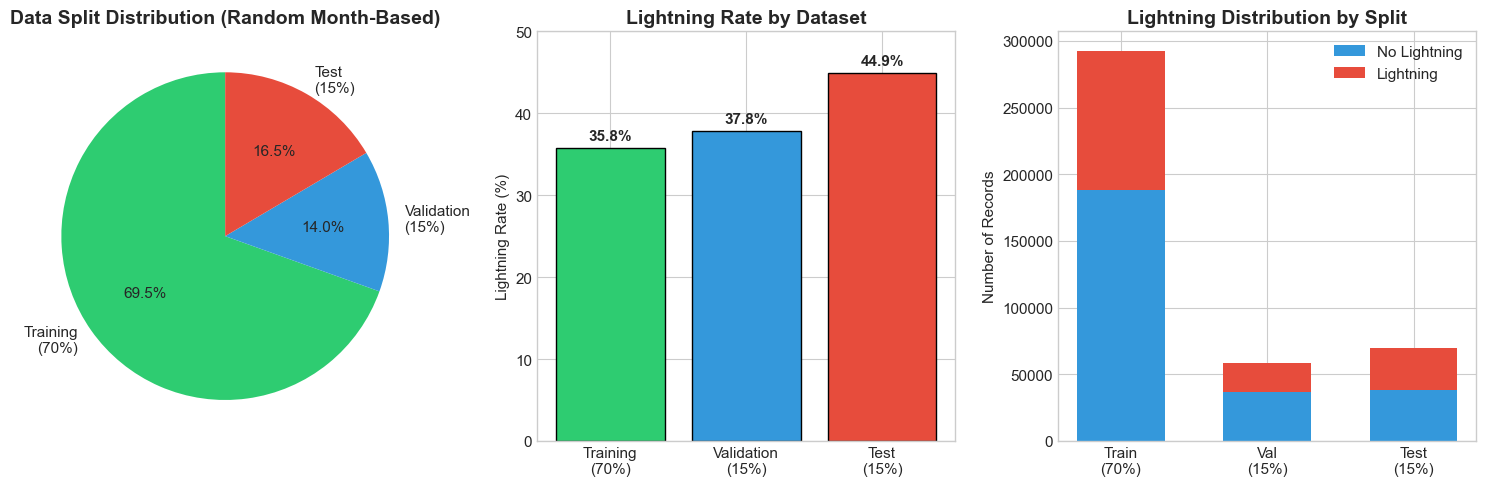


✅ Data successfully split using random month-based strategy!
   This approach ensures:
   • No temporal leakage between splits
   • Data from all years is mixed across train/val/test
   • Better generalization and reduced overfitting risk


In [3]:
# =============================================================================
# STEP 2: SPLIT DATA INTO TRAIN/VALIDATION/TEST SETS (70/15/15)
# =============================================================================
# Using random month-based splitting to avoid overfitting from year-based splits
# This ensures each split contains data from different months across all years

import random

# Convert DateTime to proper datetime format
df['DateTime'] = pd.to_datetime(df['DateTime'])

# Create a unique identifier for each year-month combination
df['Year_Month'] = df['DateTime'].dt.to_period('M')

# Get all unique year-month combinations
unique_months = df['Year_Month'].unique().tolist()
print(f"Total unique months in dataset: {len(unique_months)}")

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

# Shuffle the months randomly
random.shuffle(unique_months)

# Calculate split indices for 70/15/15 split
n_months = len(unique_months)
train_end = int(n_months * 0.70)
val_end = int(n_months * 0.85)

# Assign months to each split
train_months = unique_months[:train_end]
val_months = unique_months[train_end:val_end]
test_months = unique_months[val_end:]

print(f"\nMonths allocated:")
print(f"   Training:   {len(train_months)} months")
print(f"   Validation: {len(val_months)} months")
print(f"   Test:       {len(test_months)} months")

# Split data based on assigned months
df_train = df[df['Year_Month'].isin(train_months)].copy()
df_val = df[df['Year_Month'].isin(val_months)].copy()
df_test = df[df['Year_Month'].isin(test_months)].copy()

# Drop the temporary Year_Month column
df_train = df_train.drop(columns=['Year_Month'])
df_val = df_val.drop(columns=['Year_Month'])
df_test = df_test.drop(columns=['Year_Month'])
df = df.drop(columns=['Year_Month'])

print("\n" + "="*80)
print("📊 RANDOM MONTH-BASED DATA DISTRIBUTION (70/15/15 Split)")
print("="*80)
print(f"\n🎯 Training Set:   {len(df_train):,} rows ({len(df_train)/len(df)*100:.1f}%)")
print(f"🎯 Validation Set: {len(df_val):,} rows ({len(df_val)/len(df)*100:.1f}%)")
print(f"🎯 Test Set:       {len(df_test):,} rows ({len(df_test)/len(df)*100:.1f}%)")

# Show which months are in each split
print("\n" + "="*80)
print("📅 MONTHS IN EACH SPLIT")
print("="*80)
print(f"\nTraining months ({len(train_months)}):")
train_months_str = sorted([str(m) for m in train_months])
print(f"   {', '.join(train_months_str[:10])}{'...' if len(train_months_str) > 10 else ''}")

print(f"\nValidation months ({len(val_months)}):")
val_months_str = sorted([str(m) for m in val_months])
print(f"   {', '.join(val_months_str)}")

print(f"\nTest months ({len(test_months)}):")
test_months_str = sorted([str(m) for m in test_months])
print(f"   {', '.join(test_months_str)}")

print("\n" + "="*80)
print("⚡ LIGHTNING RATE BY SPLIT")
print("="*80)
for name, data in [('Training', df_train), ('Validation', df_val), ('Test', df_test)]:
    lightning_rate = data['Lightning_Occurred'].mean() * 100
    lightning_count = data['Lightning_Occurred'].sum()
    no_lightning_count = len(data) - lightning_count
    print(f"\n{name}:")
    print(f"   ⚡ Lightning Events: {lightning_count:,} ({lightning_rate:.2f}%)")
    print(f"   ☀️  No Lightning:     {no_lightning_count:,} ({100-lightning_rate:.2f}%)")

# Verify year distribution in each split (to show randomness)
print("\n" + "="*80)
print("📆 YEAR DISTRIBUTION IN EACH SPLIT (showing random mixing)")
print("="*80)
for name, data in [('Training', df_train), ('Validation', df_val), ('Test', df_test)]:
    year_dist = data['Year'].value_counts().sort_index()
    print(f"\n{name}:")
    for year, count in year_dist.items():
        pct = count / len(data) * 100
        print(f"   {year}: {count:,} rows ({pct:.1f}%)")

# Visualize the split
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ['#2ecc71', '#3498db', '#e74c3c']
labels = ['Training\n(70%)', 'Validation\n(15%)', 'Test\n(15%)']
sizes = [len(df_train), len(df_val), len(df_test)]

# Pie chart for data distribution
axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Data Split Distribution (Random Month-Based)', fontsize=14, fontweight='bold')

# Bar chart for lightning rates
lightning_rates = [df_train['Lightning_Occurred'].mean()*100, 
                   df_val['Lightning_Occurred'].mean()*100,
                   df_test['Lightning_Occurred'].mean()*100]
bars = axes[1].bar(labels, lightning_rates, color=colors, edgecolor='black')
axes[1].set_ylabel('Lightning Rate (%)')
axes[1].set_title('Lightning Rate by Dataset', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 50)
for bar, rate in zip(bars, lightning_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                 f'{rate:.1f}%', ha='center', fontweight='bold')

# Lightning vs No Lightning stacked bar
lightning_counts = [df_train['Lightning_Occurred'].sum(), df_val['Lightning_Occurred'].sum(), df_test['Lightning_Occurred'].sum()]
no_lightning_counts = [len(df_train) - lightning_counts[0], len(df_val) - lightning_counts[1], len(df_test) - lightning_counts[2]]

x = np.arange(3)
width = 0.6
axes[2].bar(x, no_lightning_counts, width, label='No Lightning', color='#3498db')
axes[2].bar(x, lightning_counts, width, bottom=no_lightning_counts, label='Lightning', color='#e74c3c')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Train\n(70%)', 'Val\n(15%)', 'Test\n(15%)'])
axes[2].set_ylabel('Number of Records')
axes[2].set_title('Lightning Distribution by Split', fontsize=14, fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

print("\n✅ Data successfully split using random month-based strategy!")
print("   This approach ensures:")
print("   • No temporal leakage between splits")
print("   • Data from all years is mixed across train/val/test")
print("   • Better generalization and reduced overfitting risk")

🔍 MISSING VALUES ANALYSIS

⚠️ Columns with Missing Values:
              Missing Count  Missing %
Pressure_kPa         420864      100.0


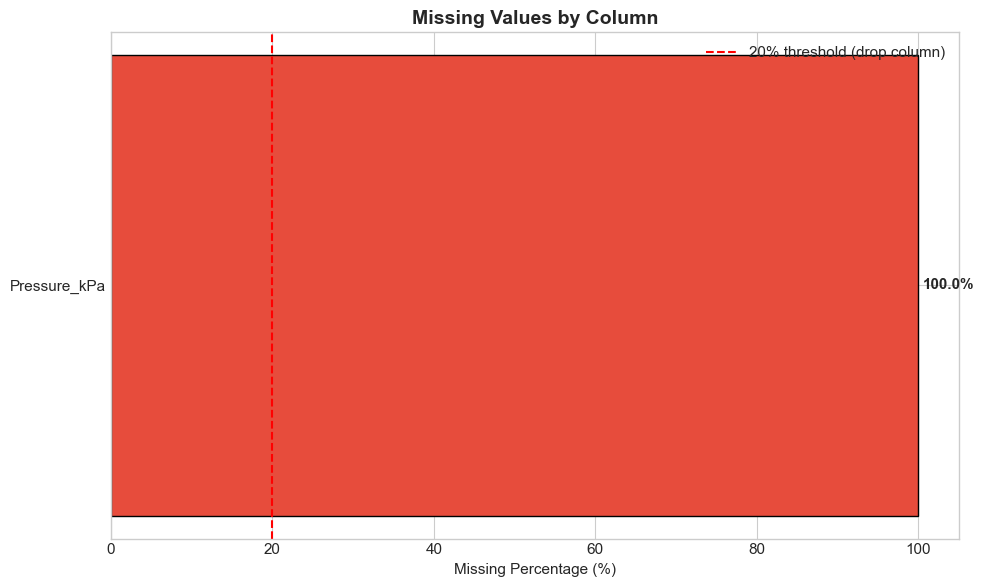


📅 MISSING VALUES BY SPLIT
Training (70%): 292,608 missing values
Validation (15%): 58,752 missing values
Test (15%): 69,504 missing values


In [4]:
# =============================================================================
# STEP 3: MISSING VALUES ANALYSIS
# =============================================================================

print("="*80)
print("🔍 MISSING VALUES ANALYSIS")
print("="*80)

# Calculate missing values
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent
}).sort_values('Missing %', ascending=False)

# Filter columns with missing values
missing_cols = missing_df[missing_df['Missing Count'] > 0]

if len(missing_cols) > 0:
    print("\n⚠️ Columns with Missing Values:")
    print(missing_cols)
    
    # Visualize missing values
    if len(missing_cols) <= 10:
        fig, ax = plt.subplots(figsize=(10, 6))
        colors = ['#e74c3c' if pct > 20 else '#f39c12' if pct > 5 else '#2ecc71' 
                  for pct in missing_cols['Missing %']]
        bars = ax.barh(missing_cols.index, missing_cols['Missing %'], color=colors, edgecolor='black')
        ax.set_xlabel('Missing Percentage (%)')
        ax.set_title('Missing Values by Column', fontsize=14, fontweight='bold')
        ax.axvline(x=20, color='red', linestyle='--', label='20% threshold (drop column)')
        ax.legend()
        for bar, pct in zip(bars, missing_cols['Missing %']):
            ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
                    f'{pct:.1f}%', va='center', fontweight='bold')
        plt.tight_layout()
        plt.show()
else:
    print("\n✅ No missing values found in the dataset!")

# Check missing values by split
print("\n" + "="*80)
print("📅 MISSING VALUES BY SPLIT")
print("="*80)
for name, data in [('Training (70%)', df_train), ('Validation (15%)', df_val), ('Test (15%)', df_test)]:
    total_missing = data.isnull().sum().sum()
    print(f"{name}: {total_missing:,} missing values")

In [5]:
# =============================================================================
# HANDLE MISSING VALUES
# =============================================================================

print("="*80)
print("🔧 HANDLING MISSING VALUES")
print("="*80)

# Drop Pressure_kPa column (100% missing)
if 'Pressure_kPa' in df.columns:
    print("\n❌ Dropping 'Pressure_kPa' column (100% missing)")
    df = df.drop(columns=['Pressure_kPa'])
    df_train = df_train.drop(columns=['Pressure_kPa'])
    df_val = df_val.drop(columns=['Pressure_kPa'])
    df_test = df_test.drop(columns=['Pressure_kPa'])
    print(f"✅ New shape: {df.shape}")

# Verify no missing values remain
remaining_missing = df.isnull().sum().sum()
print(f"\n✅ Remaining missing values: {remaining_missing}")

# Show updated columns
print(f"\n📋 Updated columns ({len(df.columns)}):")
print(df.columns.tolist())

🔧 HANDLING MISSING VALUES

❌ Dropping 'Pressure_kPa' column (100% missing)
✅ New shape: (420864, 33)

✅ Remaining missing values: 0

📋 Updated columns (33):
['DateTime', 'Date', 'Time', 'Year', 'District', 'Location', 'Latitude', 'Longitude', 'Temperature_C', 'Humidity_%', 'Wind_Speed_m/s', 'Precipitation_mm', 'Month', 'Hour', 'Minute', 'Lightning_Occurred', 'Lightning_Probability', 'Flash_Count', 'Flash_Density_per_km2', 'Expected_Flashes', 'Base_Flash_Rate', 'Time_Factor', 'Weather_Factor', 'Season', 'Time_Category', 'Month_Sin', 'Month_Cos', 'Hour_Sin', 'Hour_Cos', 'Temp_Deviation', 'Has_Precipitation', 'High_Humidity', 'Strong_Wind']


📊 OUTLIER DETECTION - PHYSICAL LIMITS

📈 Current Weather Variable Ranges:

⚠️ Temperature_C:
   Current Range: [6.34, 47.14]
   Physical Limits: [10, 45]
   Below Limit: 1,184 | Above Limit: 36

⚠️ Humidity_%:
   Current Range: [6.01, 100.00]
   Physical Limits: [30, 100]
   Below Limit: 11,648 | Above Limit: 0

✅ Wind_Speed_m/s:
   Current Range: [0.01, 14.06]
   Physical Limits: [0, 15]
   Below Limit: 0 | Above Limit: 0

⚠️ Precipitation_mm:
   Current Range: [0.00, 1270.57]
   Physical Limits: [0, 100]
   Below Limit: 0 | Above Limit: 4,660


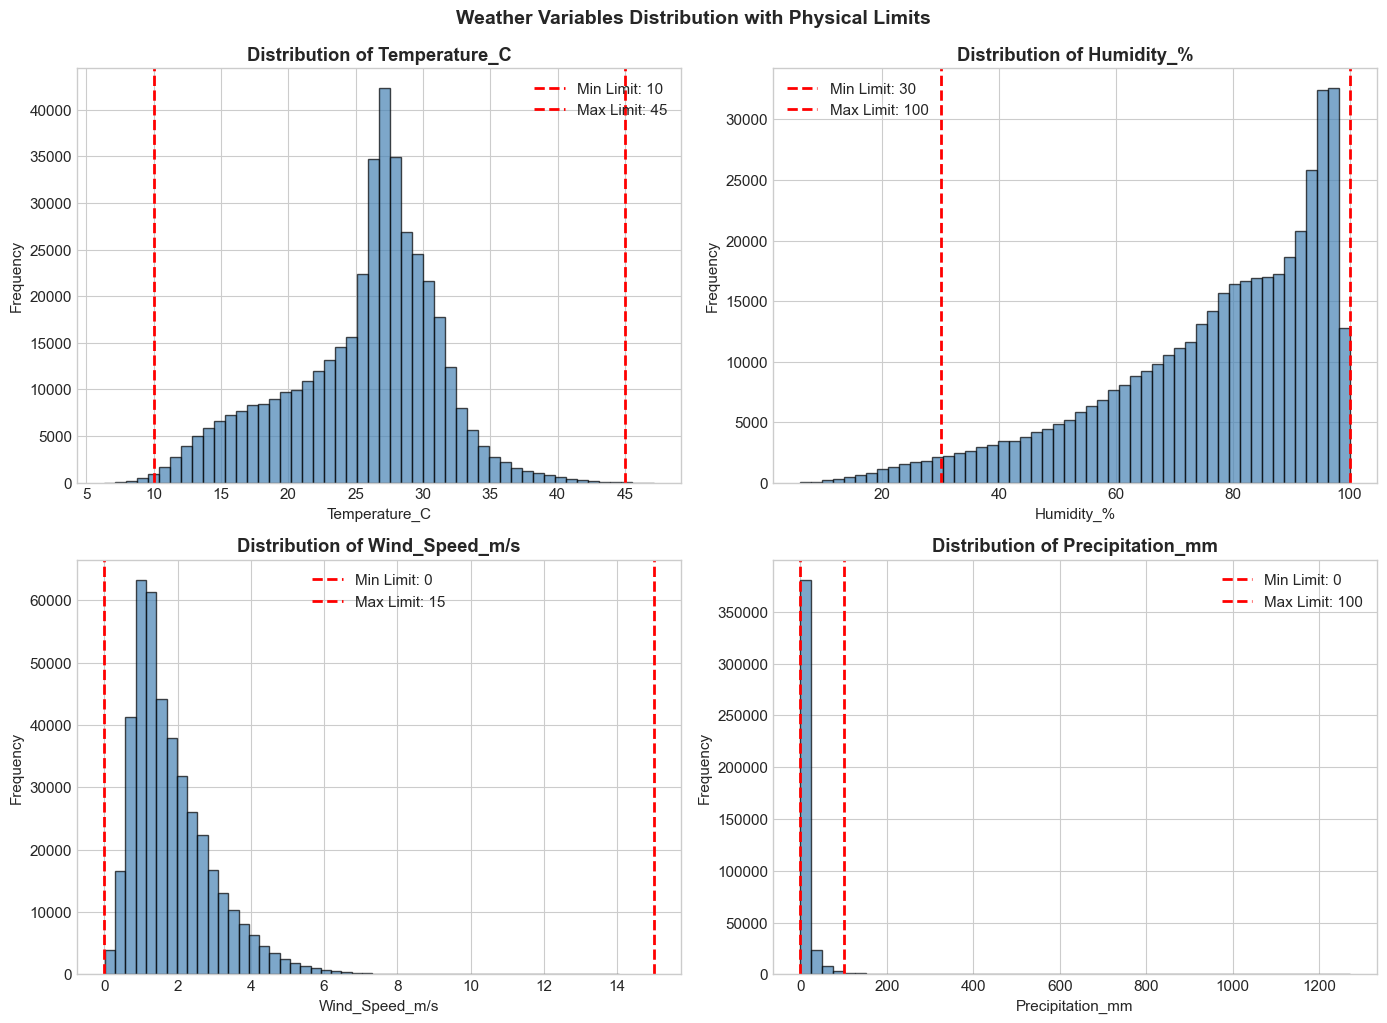

In [6]:
# =============================================================================
# STEP 4: OUTLIER DETECTION - PHYSICAL LIMITS (Bangladesh Climate)
# =============================================================================

print("="*80)
print("📊 OUTLIER DETECTION - PHYSICAL LIMITS")
print("="*80)

# Define physical limits for Bangladesh climate
physical_limits = {
    'Temperature_C': (10, 45),      # Bangladesh temp range
    'Humidity_%': (30, 100),        # Valid humidity range
    'Wind_Speed_m/s': (0, 15),      # Realistic wind speed
    'Precipitation_mm': (0, 100)     # 30-min precipitation limit
}

# Check current values against physical limits
print("\n📈 Current Weather Variable Ranges:")
weather_cols = ['Temperature_C', 'Humidity_%', 'Wind_Speed_m/s', 'Precipitation_mm']

for col in weather_cols:
    min_val, max_val = df[col].min(), df[col].max()
    phys_min, phys_max = physical_limits[col]
    below_limit = (df[col] < phys_min).sum()
    above_limit = (df[col] > phys_max).sum()
    status = "✅" if below_limit == 0 and above_limit == 0 else "⚠️"
    
    print(f"\n{status} {col}:")
    print(f"   Current Range: [{min_val:.2f}, {max_val:.2f}]")
    print(f"   Physical Limits: [{phys_min}, {phys_max}]")
    print(f"   Below Limit: {below_limit:,} | Above Limit: {above_limit:,}")

# Visualize distributions with physical limits
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(weather_cols):
    ax = axes[idx]
    phys_min, phys_max = physical_limits[col]
    
    # Histogram
    ax.hist(df[col], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(phys_min, color='red', linestyle='--', linewidth=2, label=f'Min Limit: {phys_min}')
    ax.axvline(phys_max, color='red', linestyle='--', linewidth=2, label=f'Max Limit: {phys_max}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.suptitle('Weather Variables Distribution with Physical Limits', fontsize=14, fontweight='bold', y=1.02)
plt.show()

In [7]:
# =============================================================================
# OUTLIER DETECTION - IQR METHOD
# =============================================================================

print("="*80)
print("📊 OUTLIER DETECTION - IQR METHOD")
print("="*80)

def detect_outliers_iqr(data, column, multiplier=1.5):
    """Detect outliers using IQR method"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    
    outliers_below = (data[column] < lower_bound).sum()
    outliers_above = (data[column] > upper_bound).sum()
    
    return lower_bound, upper_bound, outliers_below, outliers_above

# Analyze outliers for each weather variable
print("\n📈 IQR-Based Outlier Analysis:")
outlier_summary = []

for col in weather_cols:
    lower, upper, below, above = detect_outliers_iqr(df, col)
    total_outliers = below + above
    pct_outliers = total_outliers / len(df) * 100
    
    outlier_summary.append({
        'Column': col,
        'Lower Bound': lower,
        'Upper Bound': upper,
        'Outliers Below': below,
        'Outliers Above': above,
        'Total Outliers': total_outliers,
        'Outlier %': pct_outliers
    })
    
    print(f"\n{col}:")
    print(f"   IQR Bounds: [{lower:.2f}, {upper:.2f}]")
    print(f"   Outliers: {total_outliers:,} ({pct_outliers:.2f}%)")

outlier_df = pd.DataFrame(outlier_summary)
print("\n" + "="*80)
print("📋 OUTLIER SUMMARY TABLE")
print("="*80)
outlier_df

📊 OUTLIER DETECTION - IQR METHOD

📈 IQR-Based Outlier Analysis:

Temperature_C:
   IQR Bounds: [11.94, 39.54]
   Outliers: 7,614 (1.81%)

Humidity_%:
   IQR Bounds: [25.66, 132.38]
   Outliers: 7,274 (1.73%)

Wind_Speed_m/s:
   IQR Bounds: [-0.97, 4.44]
   Outliers: 14,032 (3.33%)

Precipitation_mm:
   IQR Bounds: [-10.37, 17.27]
   Outliers: 58,104 (13.81%)

📋 OUTLIER SUMMARY TABLE


,Column,Lower Bound,Upper Bound,Outliers Below,Outliers Above,Total Outliers,Outlier %
0,Temperature_C,11.940,39.540,5788,1826,7614,1.809135
1,Humidity_%,25.660,132.380,7274,0,7274,1.728349
2,Wind_Speed_m/s,-0.965,4.435,0,14032,14032,3.334094
3,Precipitation_mm,-10.365,17.275,0,58104,58104,13.805885


🔧 APPLYING OUTLIER HANDLING
✅ Clipped Temperature_C to [10, 45]
✅ Clipped Humidity_% to [30, 100]
✅ Clipped Wind_Speed_m/s to [0, 15]
✅ Clipped Precipitation_mm to [0, 100]

📈 New Weather Variable Ranges (After Clipping):
   Temperature_C: [10.00, 45.00]
   Humidity_%: [30.00, 100.00]
   Wind_Speed_m/s: [0.01, 14.06]
   Precipitation_mm: [0.00, 100.00]


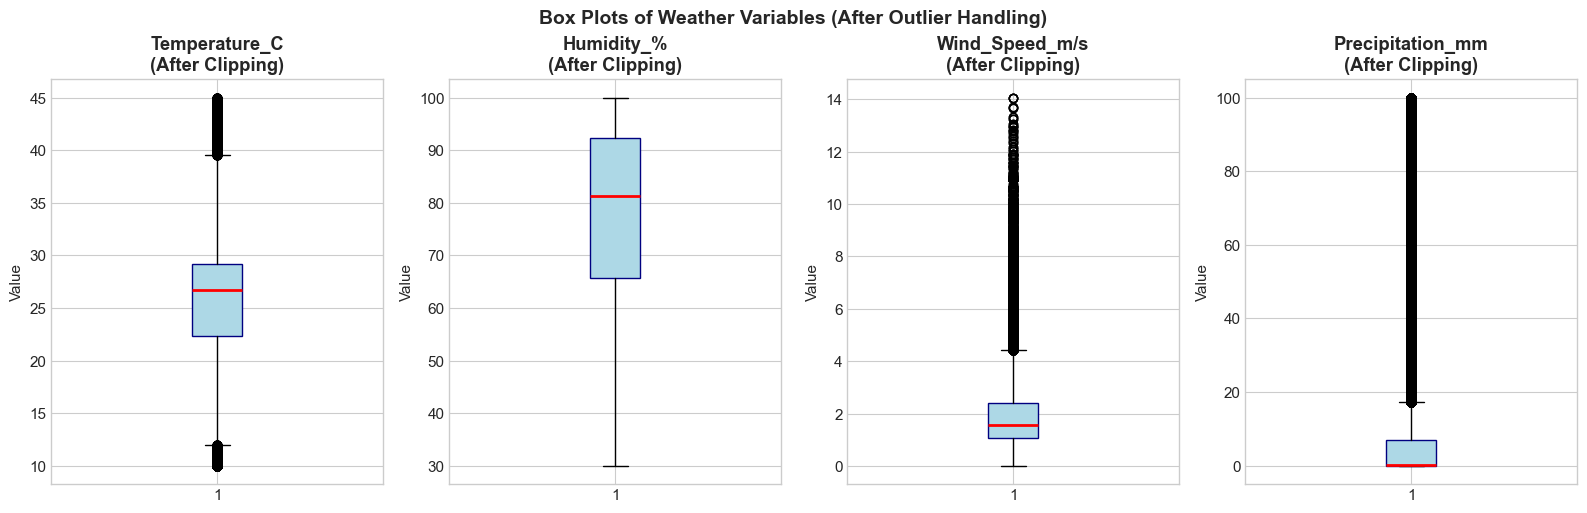


✅ Data shape preserved: 420,864 rows


In [8]:
# =============================================================================
# APPLY OUTLIER HANDLING - CLIP TO PHYSICAL LIMITS
# =============================================================================

print("="*80)
print("🔧 APPLYING OUTLIER HANDLING")
print("="*80)

# Store original shape
original_shape = df.shape[0]

# Apply physical limits clipping
for col, (min_val, max_val) in physical_limits.items():
    # Clip values to physical limits
    df[col] = df[col].clip(lower=min_val, upper=max_val)
    df_train[col] = df_train[col].clip(lower=min_val, upper=max_val)
    df_val[col] = df_val[col].clip(lower=min_val, upper=max_val)
    df_test[col] = df_test[col].clip(lower=min_val, upper=max_val)
    print(f"✅ Clipped {col} to [{min_val}, {max_val}]")

# Verify new ranges
print("\n📈 New Weather Variable Ranges (After Clipping):")
for col in weather_cols:
    print(f"   {col}: [{df[col].min():.2f}, {df[col].max():.2f}]")

# Visualize box plots before/after (showing current state)
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for idx, col in enumerate(weather_cols):
    axes[idx].boxplot(df[col].values, patch_artist=True,
                      boxprops=dict(facecolor='lightblue', color='navy'),
                      medianprops=dict(color='red', linewidth=2))
    axes[idx].set_title(f'{col}\n(After Clipping)', fontweight='bold')
    axes[idx].set_ylabel('Value')

plt.tight_layout()
plt.suptitle('Box Plots of Weather Variables (After Outlier Handling)', fontsize=14, fontweight='bold', y=1.02)
plt.show()

print(f"\n✅ Data shape preserved: {df.shape[0]:,} rows")

In [9]:
# =============================================================================
# STEP 5: FEATURE ENGINEERING
# =============================================================================

print("="*80)
print("🔧 FEATURE ENGINEERING")
print("="*80)

# Check existing features
existing_features = ['Month_Sin', 'Month_Cos', 'Hour_Sin', 'Hour_Cos', 'Season', 
                     'Time_Category', 'Temp_Deviation', 'Has_Precipitation', 
                     'High_Humidity', 'Strong_Wind']

print("\n✅ Existing Features Already in Dataset:")
for feat in existing_features:
    if feat in df.columns:
        print(f"   ✓ {feat}")
    else:
        print(f"   ✗ {feat} (missing)")

# Create additional weather-based features
print("\n🔧 Creating New Features:")

def create_features(data):
    """Create additional features for lightning prediction"""
    df_new = data.copy()
    
    # 1. Dewpoint Temperature: Td = T - ((100 - Humidity) / 5)
    df_new['Dewpoint_C'] = df_new['Temperature_C'] - ((100 - df_new['Humidity_%']) / 5)
    
    # 2. Temperature-Humidity Index (THI) - Heat Index approximation
    df_new['Temp_Humidity_Index'] = (0.8 * df_new['Temperature_C'] + 
                                      (df_new['Humidity_%'] / 100) * 
                                      (df_new['Temperature_C'] - 14.4) + 46.4)
    
    # 3. Relative humidity categories
    df_new['Humidity_Category'] = pd.cut(df_new['Humidity_%'], 
                                          bins=[0, 50, 70, 85, 100],
                                          labels=['Low', 'Medium', 'High', 'Very High'])
    
    # 4. Temperature categories
    df_new['Temp_Category'] = pd.cut(df_new['Temperature_C'],
                                      bins=[0, 20, 30, 40, 50],
                                      labels=['Cool', 'Warm', 'Hot', 'Very Hot'])
    
    # 5. Is Pre-monsoon season (high lightning season)
    df_new['Is_PreMonsoon'] = (df_new['Season'] == 'Pre-Monsoon').astype(int)
    
    # 6. Is Afternoon (peak lightning time)
    df_new['Is_Afternoon'] = (df_new['Time_Category'] == 'Afternoon').astype(int)
    
    # 7. Combined instability indicator
    df_new['Instability_Score'] = (
        (df_new['Temperature_C'] - df_new['Dewpoint_C']) / 10 +  # Higher = less stable
        df_new['Wind_Speed_m/s'] / 5 +  # Wind contribution
        df_new['Has_Precipitation'] * 2  # Precipitation indicates instability
    )
    
    return df_new

# Apply feature engineering
df = create_features(df)
df_train = create_features(df_train)
df_val = create_features(df_val)
df_test = create_features(df_test)

new_features = ['Dewpoint_C', 'Temp_Humidity_Index', 'Humidity_Category', 
                'Temp_Category', 'Is_PreMonsoon', 'Is_Afternoon', 'Instability_Score']

print("\n✅ New Features Created:")
for feat in new_features:
    print(f"   + {feat}")

print(f"\n📊 Updated Dataset Shape: {df.shape}")
print(f"\n📋 All Columns ({len(df.columns)}):")
print(df.columns.tolist())

🔧 FEATURE ENGINEERING

✅ Existing Features Already in Dataset:
   ✓ Month_Sin
   ✓ Month_Cos
   ✓ Hour_Sin
   ✓ Hour_Cos
   ✓ Season
   ✓ Time_Category
   ✓ Temp_Deviation
   ✓ Has_Precipitation
   ✓ High_Humidity
   ✓ Strong_Wind

🔧 Creating New Features:

✅ New Features Created:
   + Dewpoint_C
   + Temp_Humidity_Index
   + Humidity_Category
   + Temp_Category
   + Is_PreMonsoon
   + Is_Afternoon
   + Instability_Score

📊 Updated Dataset Shape: (420864, 40)

📋 All Columns (40):
['DateTime', 'Date', 'Time', 'Year', 'District', 'Location', 'Latitude', 'Longitude', 'Temperature_C', 'Humidity_%', 'Wind_Speed_m/s', 'Precipitation_mm', 'Month', 'Hour', 'Minute', 'Lightning_Occurred', 'Lightning_Probability', 'Flash_Count', 'Flash_Density_per_km2', 'Expected_Flashes', 'Base_Flash_Rate', 'Time_Factor', 'Weather_Factor', 'Season', 'Time_Category', 'Month_Sin', 'Month_Cos', 'Hour_Sin', 'Hour_Cos', 'Temp_Deviation', 'Has_Precipitation', 'High_Humidity', 'Strong_Wind', 'Dewpoint_C', 'Temp_Humidi

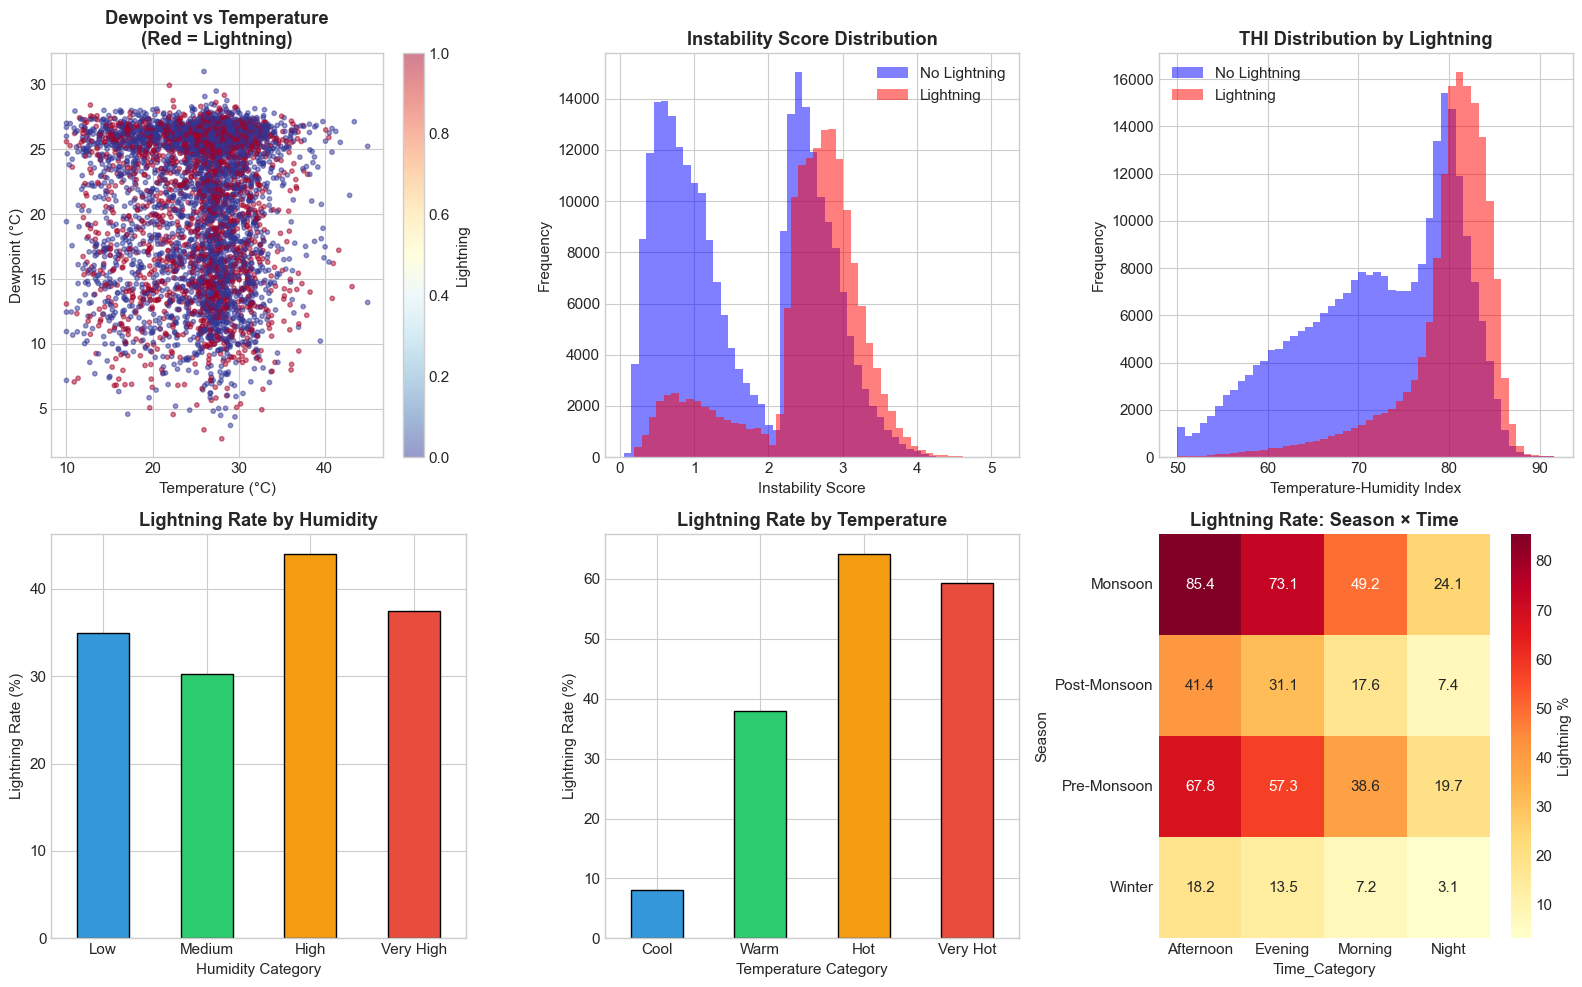

In [10]:
# =============================================================================
# VISUALIZE NEW FEATURES
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Dewpoint vs Temperature colored by Lightning
ax = axes[0, 0]
scatter = ax.scatter(df.sample(5000)['Temperature_C'], 
                     df.sample(5000)['Dewpoint_C'],
                     c=df.sample(5000)['Lightning_Occurred'], 
                     cmap='RdYlBu_r', alpha=0.5, s=10)
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Dewpoint (°C)')
ax.set_title('Dewpoint vs Temperature\n(Red = Lightning)', fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Lightning')

# 2. Instability Score distribution by Lightning
ax = axes[0, 1]
df[df['Lightning_Occurred']==0]['Instability_Score'].hist(ax=ax, bins=50, alpha=0.5, label='No Lightning', color='blue')
df[df['Lightning_Occurred']==1]['Instability_Score'].hist(ax=ax, bins=50, alpha=0.5, label='Lightning', color='red')
ax.set_xlabel('Instability Score')
ax.set_ylabel('Frequency')
ax.set_title('Instability Score Distribution', fontweight='bold')
ax.legend()

# 3. Temperature-Humidity Index distribution
ax = axes[0, 2]
df[df['Lightning_Occurred']==0]['Temp_Humidity_Index'].hist(ax=ax, bins=50, alpha=0.5, label='No Lightning', color='blue')
df[df['Lightning_Occurred']==1]['Temp_Humidity_Index'].hist(ax=ax, bins=50, alpha=0.5, label='Lightning', color='red')
ax.set_xlabel('Temperature-Humidity Index')
ax.set_ylabel('Frequency')
ax.set_title('THI Distribution by Lightning', fontweight='bold')
ax.legend()

# 4. Lightning rate by Humidity Category
ax = axes[1, 0]
lightning_by_humidity = df.groupby('Humidity_Category')['Lightning_Occurred'].mean() * 100
lightning_by_humidity.plot(kind='bar', ax=ax, color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black')
ax.set_xlabel('Humidity Category')
ax.set_ylabel('Lightning Rate (%)')
ax.set_title('Lightning Rate by Humidity', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# 5. Lightning rate by Temperature Category
ax = axes[1, 1]
lightning_by_temp = df.groupby('Temp_Category')['Lightning_Occurred'].mean() * 100
lightning_by_temp.plot(kind='bar', ax=ax, color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black')
ax.set_xlabel('Temperature Category')
ax.set_ylabel('Lightning Rate (%)')
ax.set_title('Lightning Rate by Temperature', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# 6. Season + Time Category heatmap
ax = axes[1, 2]
pivot = df.groupby(['Season', 'Time_Category'])['Lightning_Occurred'].mean().unstack() * 100
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Lightning %'})
ax.set_title('Lightning Rate: Season × Time', fontweight='bold')

plt.tight_layout()
plt.show()

In [11]:
# =============================================================================
# STEP 6: DATA NORMALIZATION (Z-Score)
# =============================================================================

print("="*80)
print("📏 DATA NORMALIZATION (Z-Score Standardization)")
print("="*80)

# Define numerical features to normalize
numerical_features = [
    'Temperature_C', 'Humidity_%', 'Wind_Speed_m/s', 'Precipitation_mm',
    'Month_Sin', 'Month_Cos', 'Hour_Sin', 'Hour_Cos', 'Temp_Deviation',
    'Dewpoint_C', 'Temp_Humidity_Index', 'Instability_Score',
    'Lightning_Probability', 'Flash_Density_per_km2', 'Expected_Flashes',
    'Base_Flash_Rate', 'Time_Factor', 'Weather_Factor'
]

# Filter to only existing columns
numerical_features = [col for col in numerical_features if col in df_train.columns]

print(f"\n📋 Features to Normalize ({len(numerical_features)}):")
for feat in numerical_features:
    print(f"   • {feat}")

# Calculate mean and std from TRAINING data only (important!)
print("\n🔧 Calculating normalization parameters from TRAINING data only...")
train_means = df_train[numerical_features].mean()
train_stds = df_train[numerical_features].std()

# Store normalization parameters
norm_params = pd.DataFrame({
    'Feature': numerical_features,
    'Mean': train_means.values,
    'Std': train_stds.values
})
print("\n📊 Normalization Parameters (from Training Set):")
print(norm_params.round(4))

# Apply Z-score normalization
def normalize_data(data, means, stds, features):
    """Apply Z-score normalization: (x - mean) / std"""
    df_norm = data.copy()
    for feat in features:
        df_norm[f'{feat}_norm'] = (df_norm[feat] - means[feat]) / stds[feat]
    return df_norm

# Apply normalization to all splits
df_train_norm = normalize_data(df_train, train_means, train_stds, numerical_features)
df_val_norm = normalize_data(df_val, train_means, train_stds, numerical_features)
df_test_norm = normalize_data(df_test, train_means, train_stds, numerical_features)

print("\n✅ Normalization Applied to All Splits")
print(f"   Training: {df_train_norm.shape}")
print(f"   Validation: {df_val_norm.shape}")
print(f"   Test: {df_test_norm.shape}")

# Verify normalization on training data
print("\n📈 Verification (Training Set - Normalized Features):")
norm_cols = [f'{feat}_norm' for feat in numerical_features[:5]]
print(f"   Mean (should be ~0): {df_train_norm[norm_cols].mean().values.round(4)}")
print(f"   Std (should be ~1):  {df_train_norm[norm_cols].std().values.round(4)}")

📏 DATA NORMALIZATION (Z-Score Standardization)

📋 Features to Normalize (18):
   • Temperature_C
   • Humidity_%
   • Wind_Speed_m/s
   • Precipitation_mm
   • Month_Sin
   • Month_Cos
   • Hour_Sin
   • Hour_Cos
   • Temp_Deviation
   • Dewpoint_C
   • Temp_Humidity_Index
   • Instability_Score
   • Lightning_Probability
   • Flash_Density_per_km2
   • Expected_Flashes
   • Base_Flash_Rate
   • Time_Factor
   • Weather_Factor

🔧 Calculating normalization parameters from TRAINING data only...

📊 Normalization Parameters (from Training Set):
                  Feature     Mean      Std
0           Temperature_C  24.9715   5.7006
1              Humidity_%  77.8048  17.6630
2          Wind_Speed_m/s   1.8530   1.1500
3        Precipitation_mm   7.8311  17.4338
4               Month_Sin  -0.0619   0.6955
5               Month_Cos   0.0712   0.7123
6                Hour_Sin  -0.0000   0.7071
7                Hour_Cos  -0.0000   0.7071
8          Temp_Deviation  -0.0000   3.2444
9            

In [13]:
# =============================================================================
# STEP 7: ONE-HOT ENCODING FOR CATEGORICAL FEATURES
# =============================================================================

print("="*80)
print("🏷️ ONE-HOT ENCODING FOR CATEGORICAL FEATURES")
print("="*80)

# Identify categorical columns for one-hot encoding
categorical_cols = ['District', 'Season', 'Time_Category', 'Humidity_Category', 'Temp_Category']
categorical_cols = [col for col in categorical_cols if col in df_train_norm.columns]

print(f"\n📋 Categorical Columns to One-Hot Encode:")
for col in categorical_cols:
    unique_vals = df_train_norm[col].nunique()
    print(f"   • {col}: {unique_vals} unique values")
    print(f"     Values: {list(df_train_norm[col].unique())}")

# Apply One-Hot Encoding using pandas get_dummies
print("\n" + "-"*60)
print("🔄 Applying One-Hot Encoding...")
print("-"*60)

# One-Hot Encode categorical columns with dtype uint8 to save memory
df_train_encoded = pd.get_dummies(df_train_norm, columns=categorical_cols, prefix_sep='_', drop_first=False, dtype='uint8')
df_val_encoded = pd.get_dummies(df_val_norm, columns=categorical_cols, prefix_sep='_', drop_first=False, dtype='uint8')
df_test_encoded = pd.get_dummies(df_test_norm, columns=categorical_cols, prefix_sep='_', drop_first=False, dtype='uint8')

# Get all unique columns from all datasets
all_columns = set(df_train_encoded.columns) | set(df_val_encoded.columns) | set(df_test_encoded.columns)

# Add missing columns with zeros (memory efficient approach)
for col in all_columns:
    if col not in df_train_encoded.columns:
        df_train_encoded[col] = np.uint8(0)
    if col not in df_val_encoded.columns:
        df_val_encoded[col] = np.uint8(0)
    if col not in df_test_encoded.columns:
        df_test_encoded[col] = np.uint8(0)

# Sort columns to ensure consistency (in-place reindex)
column_order = sorted(df_train_encoded.columns.tolist())
df_train_encoded = df_train_encoded.reindex(columns=column_order, copy=False)
df_val_encoded = df_val_encoded.reindex(columns=column_order, copy=False)
df_test_encoded = df_test_encoded.reindex(columns=column_order, copy=False)

# Count new one-hot encoded columns
one_hot_cols = [col for col in df_train_encoded.columns if any(cat in col for cat in categorical_cols)]

print(f"\n✅ One-Hot Encoding Complete!")
print(f"\nOriginal columns: {len(df_train_norm.columns)}")
print(f"After One-Hot Encoding: {len(df_train_encoded.columns)}")
print(f"New One-Hot columns created: {len(one_hot_cols)}")

print(f"\n📋 One-Hot Encoded Columns:")
for col in categorical_cols:
    encoded_cols = [c for c in one_hot_cols if c.startswith(col + '_')]
    print(f"   {col} -> {len(encoded_cols)} columns: {encoded_cols[:3]}{'...' if len(encoded_cols) > 3 else ''}")

print(f"\n📊 Dataset Shapes After Encoding:")
print(f"   Training:   {df_train_encoded.shape}")
print(f"   Validation: {df_val_encoded.shape}")
print(f"   Test:       {df_test_encoded.shape}")

🏷️ ONE-HOT ENCODING FOR CATEGORICAL FEATURES

📋 Categorical Columns to One-Hot Encode:
   • District: 8 unique values
     Values: ['Barisal', 'Chittagong', 'Dhaka', 'Khulna', 'Mymensingh', 'Rajshahi', 'Rangpur', 'Sylhet']
   • Season: 4 unique values
     Values: ['Winter', 'Pre-Monsoon', 'Monsoon', 'Post-Monsoon']
   • Time_Category: 4 unique values
     Values: ['Night', 'Morning', 'Afternoon', 'Evening']
   • Humidity_Category: 4 unique values
     Values: ['High', 'Very High', 'Medium', 'Low']
   • Temp_Category: 4 unique values
     Values: ['Cool', 'Warm', 'Hot', 'Very Hot']

------------------------------------------------------------
🔄 Applying One-Hot Encoding...
------------------------------------------------------------

✅ One-Hot Encoding Complete!

Original columns: 58
After One-Hot Encoding: 77
New One-Hot columns created: 24

📋 One-Hot Encoded Columns:
   District -> 8 columns: ['District_Barisal', 'District_Chittagong', 'District_Dhaka']...
   Season -> 4 columns: ['S

In [14]:
# =============================================================================
# STEP 8: PREPARE FEATURES FOR DEEP LEARNING
# =============================================================================

print("="*80)
print("🔧 PREPARING FEATURES FOR DEEP LEARNING (RNN, GRU, LSTM)")
print("="*80)

# Remove leaky features that are derived from target
leaky_features = [
    'Lightning_Probability', 'Lightning_Probability_norm',
    'Flash_Count', 'Flash_Count_norm',
    'Flash_Density_per_km2', 'Flash_Density_per_km2_norm',
    'Expected_Flashes', 'Expected_Flashes_norm',
    'Base_Flash_Rate', 'Base_Flash_Rate_norm',
    'Time_Factor', 'Time_Factor_norm',
    'Weather_Factor', 'Weather_Factor_norm'
]

# Identify non-feature columns to exclude
# NOTE: 'Month' is excluded to prevent temporal leakage since we split by random months
# The cyclic Month_Sin and Month_Cos features capture seasonality safely
exclude_cols = ['DateTime', 'Date', 'Time', 'Year', 'Month', 'Location', 'Lightning_Occurred', 
                'Latitude', 'Longitude', 'Month_norm'] + leaky_features

print("\n⚠️ Columns excluded to prevent temporal leakage:")
print(f"   • DateTime, Date, Time - Direct temporal identifiers")
print(f"   • Year - Could reveal train/val/test split patterns")
print(f"   • Month, Month_norm - Excluded since we split by random months")
print(f"   • Location, Latitude, Longitude - Spatial identifiers")
print(f"   • Leaky features derived from target variable")

# Get feature columns (numerical and one-hot encoded)
feature_cols = [col for col in df_train_encoded.columns 
                if col not in exclude_cols and df_train_encoded[col].dtype in ['int64', 'float64', 'int32', 'float32', 'uint8']]

# Remove any remaining leaky features
feature_cols = [col for col in feature_cols if col not in leaky_features]

print(f"\n📋 Selected Features ({len(feature_cols)}):")
print(f"   First 10: {feature_cols[:10]}")
print(f"   ...and {len(feature_cols) - 10} more")

# Create X and y datasets
X_train = df_train_encoded[feature_cols].values
y_train = df_train_encoded['Lightning_Occurred'].values

X_val = df_val_encoded[feature_cols].values
y_val = df_val_encoded['Lightning_Occurred'].values

X_test = df_test_encoded[feature_cols].values
y_test = df_test_encoded['Lightning_Occurred'].values

print(f"\n📊 Feature Matrix Shapes:")
print(f"   X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"   X_val:   {X_val.shape}, y_val: {y_val.shape}")
print(f"   X_test:  {X_test.shape}, y_test: {y_test.shape}")

# Check for NaN values
print(f"\n🔍 Checking for NaN values:")
print(f"   X_train NaN: {np.isnan(X_train).sum()}")
print(f"   X_val NaN:   {np.isnan(X_val).sum()}")
print(f"   X_test NaN:  {np.isnan(X_test).sum()}")

# Fill NaN with 0 if any
X_train = np.nan_to_num(X_train, nan=0.0)
X_val = np.nan_to_num(X_val, nan=0.0)
X_test = np.nan_to_num(X_test, nan=0.0)

print("\n✅ Features prepared for deep learning!")

🔧 PREPARING FEATURES FOR DEEP LEARNING (RNN, GRU, LSTM)

⚠️ Columns excluded to prevent temporal leakage:
   • DateTime, Date, Time - Direct temporal identifiers
   • Year - Could reveal train/val/test split patterns
   • Month, Month_norm - Excluded since we split by random months
   • Location, Latitude, Longitude - Spatial identifiers
   • Leaky features derived from target variable

📋 Selected Features (55):
   First 10: ['Dewpoint_C', 'Dewpoint_C_norm', 'District_Barisal', 'District_Chittagong', 'District_Dhaka', 'District_Khulna', 'District_Mymensingh', 'District_Rajshahi', 'District_Rangpur', 'District_Sylhet']
   ...and 45 more

📊 Feature Matrix Shapes:
   X_train: (292608, 55), y_train: (292608,)
   X_val:   (58752, 55), y_val: (58752,)
   X_test:  (69504, 55), y_test: (69504,)

🔍 Checking for NaN values:
   X_train NaN: 0
   X_val NaN:   0
   X_test NaN:  0

✅ Features prepared for deep learning!


In [15]:
# =============================================================================
# RESHAPE DATA FOR SEQUENCE MODELS (RNN, GRU, LSTM)
# =============================================================================

print("="*80)
print("🔄 RESHAPING DATA FOR SEQUENCE MODELS")
print("="*80)

# For RNN/GRU/LSTM, we need 3D input: (samples, timesteps, features)
# Since we're treating each sample as a single timestep, we reshape to (samples, 1, features)
# Alternatively, we can create sequences from consecutive time points

# Option 1: Simple reshape - each sample is treated as a sequence of length 1
# This is suitable when we don't have strict temporal ordering by location

timesteps = 1  # Each sample is one timestep
n_features = X_train.shape[1]

X_train_seq = X_train.reshape((X_train.shape[0], timesteps, n_features))
X_val_seq = X_val.reshape((X_val.shape[0], timesteps, n_features))
X_test_seq = X_test.reshape((X_test.shape[0], timesteps, n_features))

print(f"\n📊 Reshaped Data for Sequence Models:")
print(f"   X_train_seq: {X_train_seq.shape} (samples, timesteps, features)")
print(f"   X_val_seq:   {X_val_seq.shape}")
print(f"   X_test_seq:  {X_test_seq.shape}")

# Calculate class weights for imbalanced data
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

print(f"\n⚖️ Class Weights for Imbalanced Data:")
print(f"   Class 0 (No Lightning): {class_weight_dict[0]:.4f}")
print(f"   Class 1 (Lightning):    {class_weight_dict[1]:.4f}")

# Store feature information for later use
print(f"\n📋 Model Input Configuration:")
print(f"   Input Shape: ({timesteps}, {n_features})")
print(f"   Number of Features: {n_features}")
print(f"   Training Samples: {len(X_train_seq)}")

print("\n✅ Data ready for RNN, GRU, and LSTM models!")

🔄 RESHAPING DATA FOR SEQUENCE MODELS

📊 Reshaped Data for Sequence Models:
   X_train_seq: (292608, 1, 55) (samples, timesteps, features)
   X_val_seq:   (58752, 1, 55)
   X_test_seq:  (69504, 1, 55)

⚖️ Class Weights for Imbalanced Data:
   Class 0 (No Lightning): 0.7785
   Class 1 (Lightning):    1.3976

📋 Model Input Configuration:
   Input Shape: (1, 55)
   Number of Features: 55
   Training Samples: 292608

✅ Data ready for RNN, GRU, and LSTM models!


In [16]:
# =============================================================================
# STEP 9: IMPORT DEEP LEARNING LIBRARIES
# =============================================================================

print("="*80)
print("🧠 IMPORTING DEEP LEARNING LIBRARIES")
print("="*80)

import os
import time

# Suppress TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, LSTM, GRU, SimpleRNN, Dropout, 
                                      BatchNormalization, Input, Bidirectional,
                                      Flatten, Concatenate)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l1_l2

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve, average_precision_score)

print(f"\n✅ TensorFlow Version: {tf.__version__}")
print(f"✅ Keras Version: {keras.__version__}")

# Check GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU Available: {len(gpus)} GPU(s)")
    for gpu in gpus:
        print(f"   • {gpu}")
else:
    print("⚠️ No GPU available. Training will use CPU.")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("\n✅ Deep learning environment ready!")

🧠 IMPORTING DEEP LEARNING LIBRARIES

✅ TensorFlow Version: 2.20.0
✅ Keras Version: 3.13.2
⚠️ No GPU available. Training will use CPU.

✅ Deep learning environment ready!


In [17]:
# =============================================================================
# STEP 10: DEFINE MODEL ARCHITECTURES
# =============================================================================

print("="*80)
print("🔨 DEFINING MODEL ARCHITECTURES (RNN, GRU, LSTM)")
print("="*80)

def build_simple_rnn(input_shape, units=64, dropout_rate=0.3):
    """Build a Simple RNN model for lightning prediction"""
    model = Sequential([
        # RNN Layer 1
        SimpleRNN(units, return_sequences=True, input_shape=input_shape,
                  kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
        BatchNormalization(),
        Dropout(dropout_rate),
        
        # RNN Layer 2
        SimpleRNN(units // 2, return_sequences=False,
                  kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
        BatchNormalization(),
        Dropout(dropout_rate),
        
        # Dense Layers
        Dense(32, activation='relu'),
        Dropout(dropout_rate / 2),
        Dense(16, activation='relu'),
        
        # Output Layer
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model

def build_gru(input_shape, units=64, dropout_rate=0.3):
    """Build a GRU model for lightning prediction"""
    model = Sequential([
        # GRU Layer 1
        GRU(units, return_sequences=True, input_shape=input_shape,
            kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
        BatchNormalization(),
        Dropout(dropout_rate),
        
        # GRU Layer 2
        GRU(units // 2, return_sequences=False,
            kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
        BatchNormalization(),
        Dropout(dropout_rate),
        
        # Dense Layers
        Dense(32, activation='relu'),
        Dropout(dropout_rate / 2),
        Dense(16, activation='relu'),
        
        # Output Layer
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model

def build_lstm(input_shape, units=64, dropout_rate=0.3):
    """Build an LSTM model for lightning prediction"""
    model = Sequential([
        # LSTM Layer 1
        LSTM(units, return_sequences=True, input_shape=input_shape,
             kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
        BatchNormalization(),
        Dropout(dropout_rate),
        
        # LSTM Layer 2
        LSTM(units // 2, return_sequences=False,
             kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
        BatchNormalization(),
        Dropout(dropout_rate),
        
        # Dense Layers
        Dense(32, activation='relu'),
        Dropout(dropout_rate / 2),
        Dense(16, activation='relu'),
        
        # Output Layer
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model

def build_bidirectional_lstm(input_shape, units=64, dropout_rate=0.3):
    """Build a Bidirectional LSTM model for lightning prediction"""
    model = Sequential([
        # Bidirectional LSTM Layer 1
        Bidirectional(LSTM(units, return_sequences=True,
                          kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
                     input_shape=input_shape),
        BatchNormalization(),
        Dropout(dropout_rate),
        
        # Bidirectional LSTM Layer 2
        Bidirectional(LSTM(units // 2, return_sequences=False,
                          kernel_regularizer=l1_l2(l1=0.01, l2=0.01))),
        BatchNormalization(),
        Dropout(dropout_rate),
        
        # Dense Layers
        Dense(64, activation='relu'),
        Dropout(dropout_rate / 2),
        Dense(32, activation='relu'),
        
        # Output Layer
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model

# Define callbacks
def get_callbacks(model_name):
    """Create callbacks for training"""
    callbacks = [
        EarlyStopping(
            monitor='val_auc',
            patience=10,
            mode='max',
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        )
    ]
    return callbacks

print("✅ Model architecture functions defined:")
print("   1. build_simple_rnn() - Simple RNN model")
print("   2. build_gru() - GRU model")
print("   3. build_lstm() - LSTM model")
print("   4. build_bidirectional_lstm() - Bidirectional LSTM model")

# Display model summary for reference
print("\n" + "-"*60)
print("📋 Sample Model Architecture (LSTM):")
print("-"*60)
sample_model = build_lstm((timesteps, n_features), units=64)
sample_model.summary()

🔨 DEFINING MODEL ARCHITECTURES (RNN, GRU, LSTM)
✅ Model architecture functions defined:
   1. build_simple_rnn() - Simple RNN model
   2. build_gru() - GRU model
   3. build_lstm() - LSTM model
   4. build_bidirectional_lstm() - Bidirectional LSTM model

------------------------------------------------------------
📋 Sample Model Architecture (LSTM):
------------------------------------------------------------


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 64)          │        30,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,121 (176.25 KB)

 Trainable params: 44,929 (175.50 KB)

 Non-trainable params: 192 (768.00 B)

In [18]:
# =============================================================================
# STEP 11: TRAIN SIMPLE RNN MODEL
# =============================================================================

print("="*80)
print("🚀 TRAINING SIMPLE RNN MODEL")
print("="*80)

# Build Simple RNN model
rnn_model = build_simple_rnn((timesteps, n_features), units=64, dropout_rate=0.3)

print("\n📋 Simple RNN Model Summary:")
rnn_model.summary()

# Training parameters
EPOCHS = 50
BATCH_SIZE = 256

print(f"\n⚙️ Training Configuration:")
print(f"   Epochs: {EPOCHS}")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Class Weights: {class_weight_dict}")

# Train the model
print("\n🔄 Training Simple RNN...")
start_time = time.time()

rnn_history = rnn_model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('SimpleRNN'),
    verbose=1
)

rnn_training_time = time.time() - start_time
print(f"\n✅ Simple RNN Training Complete! Time: {rnn_training_time:.2f}s")

# Evaluate on validation set
rnn_val_results = rnn_model.evaluate(X_val_seq, y_val, verbose=0)
print(f"\n📊 Simple RNN Validation Results:")
print(f"   Loss: {rnn_val_results[0]:.4f}")
print(f"   Accuracy: {rnn_val_results[1]:.4f}")
print(f"   AUC: {rnn_val_results[2]:.4f}")
print(f"   Precision: {rnn_val_results[3]:.4f}")
print(f"   Recall: {rnn_val_results[4]:.4f}")

🚀 TRAINING SIMPLE RNN MODEL

📋 Simple RNN Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 1, 64)          │         7,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,769 (49.88 KB)

 Trainable params: 12,577 (49.13 KB)

 Non-trainable params: 192 (768.00 B)


⚙️ Training Configuration:
   Epochs: 50
   Batch Size: 256
   Class Weights: {np.int64(0): np.float64(0.7785274898363168), np.int64(1): np.float64(1.3975774712467999)}

🔄 Training Simple RNN...
Epoch 1/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7403 - auc: 0.8090 - loss: 1.2137 - precision: 0.6132 - recall: 0.7424 - val_accuracy: 0.5127 - val_auc: 0.8061 - val_loss: 1.0729 - val_precision: 0.4354 - val_recall: 0.9698 - learning_rate: 0.0010
Epoch 2/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7590 - auc: 0.8247 - loss: 0.5756 - precision: 0.6391 - recall: 0.7498 - val_accuracy: 0.6804 - val_auc: 0.8097 - val_loss: 0.6616 - val_precision: 0.5499 - val_recall: 0.8560 - learning_rate: 0.0010
Epoch 3/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7627 - auc: 0.8263 - loss: 0.5656 - precision: 0.6461 - recall: 0.7444 - val_accuracy: 0.7424 - val_auc: 0.8122 - val_loss: 0.5834 - val_precision: 0.6402 - val_recall: 0.7293 - learning_rate: 0.0010


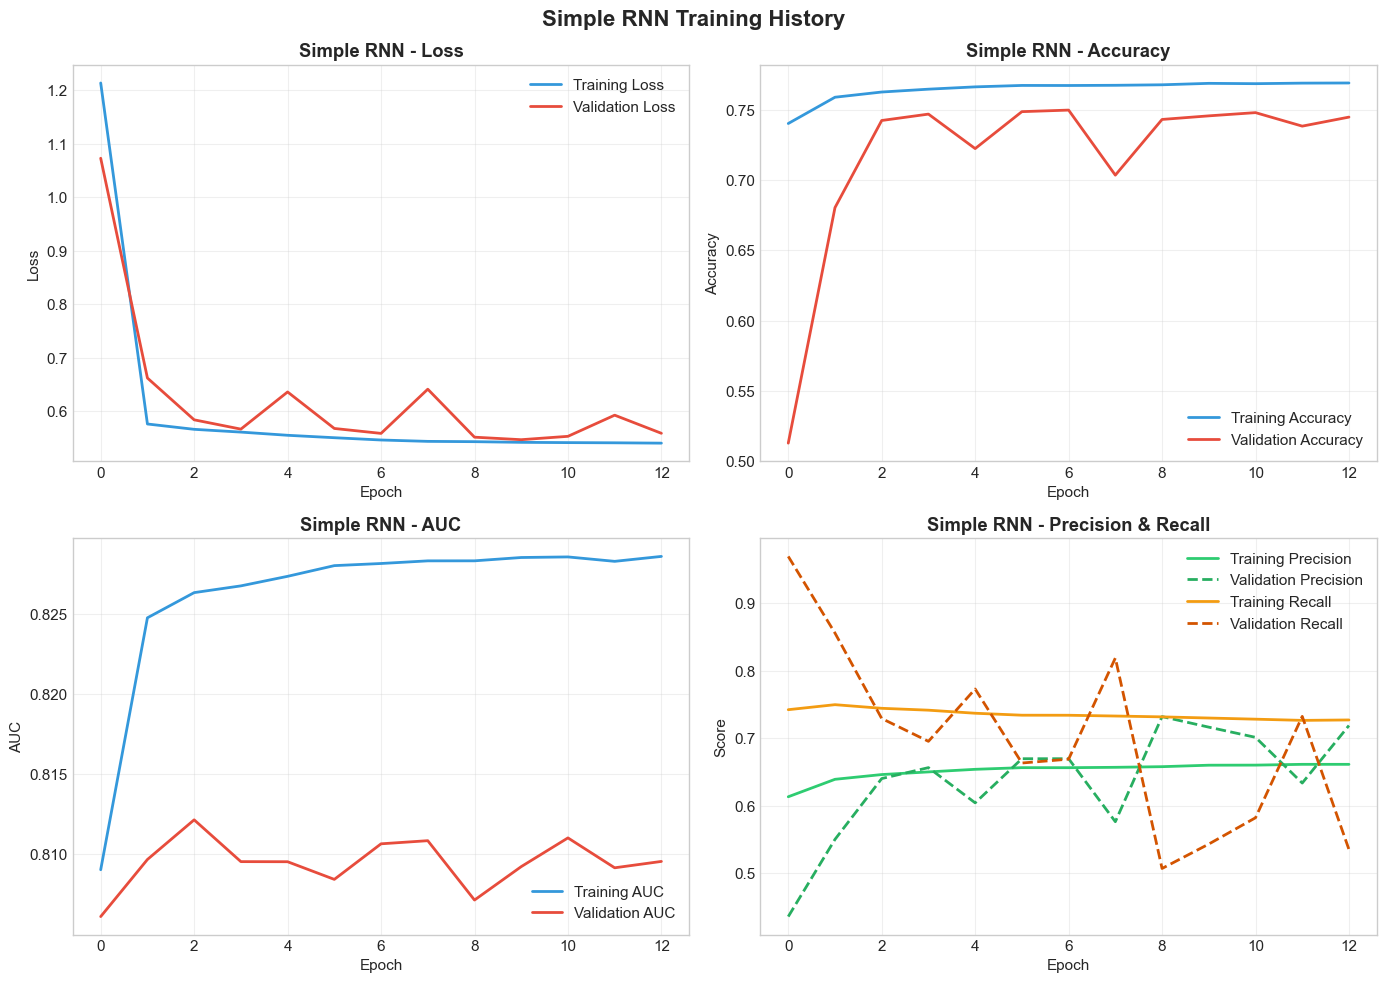

In [19]:
# =============================================================================
# PLOT SIMPLE RNN TRAINING HISTORY
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot Loss
ax = axes[0, 0]
ax.plot(rnn_history.history['loss'], label='Training Loss', color='#3498db', linewidth=2)
ax.plot(rnn_history.history['val_loss'], label='Validation Loss', color='#e74c3c', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Simple RNN - Loss', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot Accuracy
ax = axes[0, 1]
ax.plot(rnn_history.history['accuracy'], label='Training Accuracy', color='#3498db', linewidth=2)
ax.plot(rnn_history.history['val_accuracy'], label='Validation Accuracy', color='#e74c3c', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Simple RNN - Accuracy', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot AUC
ax = axes[1, 0]
ax.plot(rnn_history.history['auc'], label='Training AUC', color='#3498db', linewidth=2)
ax.plot(rnn_history.history['val_auc'], label='Validation AUC', color='#e74c3c', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('AUC')
ax.set_title('Simple RNN - AUC', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot Precision & Recall
ax = axes[1, 1]
ax.plot(rnn_history.history['precision'], label='Training Precision', color='#2ecc71', linewidth=2)
ax.plot(rnn_history.history['val_precision'], label='Validation Precision', color='#27ae60', linewidth=2, linestyle='--')
ax.plot(rnn_history.history['recall'], label='Training Recall', color='#f39c12', linewidth=2)
ax.plot(rnn_history.history['val_recall'], label='Validation Recall', color='#d35400', linewidth=2, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('Score')
ax.set_title('Simple RNN - Precision & Recall', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Simple RNN Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# =============================================================================
# STEP 12: TRAIN GRU MODEL
# =============================================================================

print("="*80)
print("🚀 TRAINING GRU MODEL")
print("="*80)

# Build GRU model
gru_model = build_gru((timesteps, n_features), units=64, dropout_rate=0.3)

print("\n📋 GRU Model Summary:")
gru_model.summary()

# Train the model
print("\n🔄 Training GRU...")
start_time = time.time()

gru_history = gru_model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('GRU'),
    verbose=1
)

gru_training_time = time.time() - start_time
print(f"\n✅ GRU Training Complete! Time: {gru_training_time:.2f}s")

# Evaluate on validation set
gru_val_results = gru_model.evaluate(X_val_seq, y_val, verbose=0)
print(f"\n📊 GRU Validation Results:")
print(f"   Loss: {gru_val_results[0]:.4f}")
print(f"   Accuracy: {gru_val_results[1]:.4f}")
print(f"   AUC: {gru_val_results[2]:.4f}")
print(f"   Precision: {gru_val_results[3]:.4f}")
print(f"   Recall: {gru_val_results[4]:.4f}")

🚀 TRAINING GRU MODEL

📋 GRU Model Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 1, 64)          │        23,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,625 (135.25 KB)

 Trainable params: 34,433 (134.50 KB)

 Non-trainable params: 192 (768.00 B)


🔄 Training GRU...
Epoch 1/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7462 - auc: 0.8141 - loss: 1.4680 - precision: 0.6201 - recall: 0.7501 - val_accuracy: 0.7181 - val_auc: 0.8083 - val_loss: 0.6276 - val_precision: 0.5970 - val_recall: 0.7853 - learning_rate: 0.0010
Epoch 2/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7614 - auc: 0.8247 - loss: 0.5813 - precision: 0.6431 - recall: 0.7484 - val_accuracy: 0.7437 - val_auc: 0.8095 - val_loss: 0.5842 - val_precision: 0.6485 - val_recall: 0.7046 - learning_rate: 0.0010
Epoch 3/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7643 - auc: 0.8260 - loss: 0.5695 - precision: 0.6491 - recall: 0.7424 - val_accuracy: 0.7223 - val_auc: 0.8077 - val_loss: 0.6082 - val_precision: 0.6034 - val_recall: 0.7770 - learning_rate: 0.0010
Epoch 4/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7663 - auc: 0.8269 - loss: 0.5627 - precision: 0.6537 - recall: 0.7373 - val_accuracy: 0.7387 - val_auc: 0.80

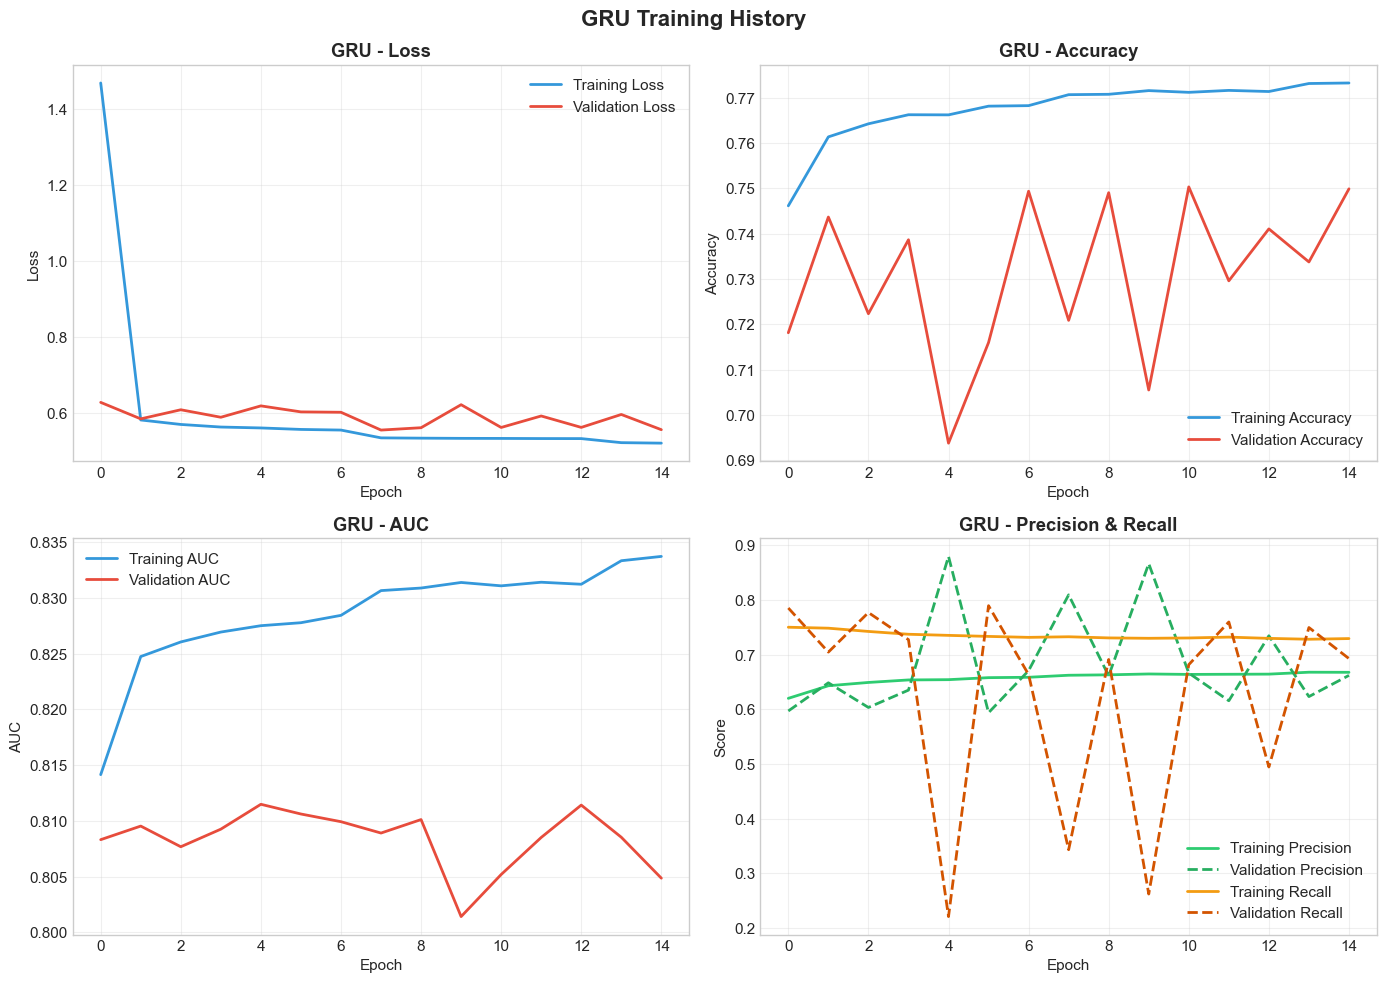

In [21]:
# =============================================================================
# PLOT GRU TRAINING HISTORY
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot Loss
ax = axes[0, 0]
ax.plot(gru_history.history['loss'], label='Training Loss', color='#3498db', linewidth=2)
ax.plot(gru_history.history['val_loss'], label='Validation Loss', color='#e74c3c', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('GRU - Loss', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot Accuracy
ax = axes[0, 1]
ax.plot(gru_history.history['accuracy'], label='Training Accuracy', color='#3498db', linewidth=2)
ax.plot(gru_history.history['val_accuracy'], label='Validation Accuracy', color='#e74c3c', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('GRU - Accuracy', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot AUC
ax = axes[1, 0]
ax.plot(gru_history.history['auc'], label='Training AUC', color='#3498db', linewidth=2)
ax.plot(gru_history.history['val_auc'], label='Validation AUC', color='#e74c3c', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('AUC')
ax.set_title('GRU - AUC', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot Precision & Recall
ax = axes[1, 1]
ax.plot(gru_history.history['precision'], label='Training Precision', color='#2ecc71', linewidth=2)
ax.plot(gru_history.history['val_precision'], label='Validation Precision', color='#27ae60', linewidth=2, linestyle='--')
ax.plot(gru_history.history['recall'], label='Training Recall', color='#f39c12', linewidth=2)
ax.plot(gru_history.history['val_recall'], label='Validation Recall', color='#d35400', linewidth=2, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('Score')
ax.set_title('GRU - Precision & Recall', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('GRU Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# =============================================================================
# STEP 13: TRAIN LSTM MODEL
# =============================================================================

print("="*80)
print("🚀 TRAINING LSTM MODEL")
print("="*80)

# Build LSTM model
lstm_model = build_lstm((timesteps, n_features), units=64, dropout_rate=0.3)

print("\n📋 LSTM Model Summary:")
lstm_model.summary()

# Train the model
print("\n🔄 Training LSTM...")
start_time = time.time()

lstm_history = lstm_model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('LSTM'),
    verbose=1
)

lstm_training_time = time.time() - start_time
print(f"\n✅ LSTM Training Complete! Time: {lstm_training_time:.2f}s")

# Evaluate on validation set
lstm_val_results = lstm_model.evaluate(X_val_seq, y_val, verbose=0)
print(f"\n📊 LSTM Validation Results:")
print(f"   Loss: {lstm_val_results[0]:.4f}")
print(f"   Accuracy: {lstm_val_results[1]:.4f}")
print(f"   AUC: {lstm_val_results[2]:.4f}")
print(f"   Precision: {lstm_val_results[3]:.4f}")
print(f"   Recall: {lstm_val_results[4]:.4f}")

🚀 TRAINING LSTM MODEL

📋 LSTM Model Summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 1, 64)          │        30,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 1, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,121 (176.25 KB)

 Trainable params: 44,929 (175.50 KB)

 Non-trainable params: 192 (768.00 B)


🔄 Training LSTM...
Epoch 1/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7486 - auc: 0.8129 - loss: 1.5354 - precision: 0.6247 - recall: 0.7446 - val_accuracy: 0.7208 - val_auc: 0.8112 - val_loss: 0.6289 - val_precision: 0.6005 - val_recall: 0.7833 - learning_rate: 0.0010
Epoch 2/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7639 - auc: 0.8247 - loss: 0.5795 - precision: 0.6494 - recall: 0.7393 - val_accuracy: 0.6717 - val_auc: 0.8099 - val_loss: 0.6614 - val_precision: 0.8951 - val_recall: 0.1501 - learning_rate: 0.0010
Epoch 3/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7662 - auc: 0.8258 - loss: 0.5725 - precision: 0.6547 - recall: 0.7334 - val_accuracy: 0.7471 - val_auc: 0.8103 - val_loss: 0.5860 - val_precision: 0.7063 - val_recall: 0.5680 - learning_rate: 0.0010
Epoch 4/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7662 - auc: 0.8268 - loss: 0.5691 - precision: 0.6542 - recall: 0.7353 - val_accuracy: 0.7474 - val_auc: 0.8

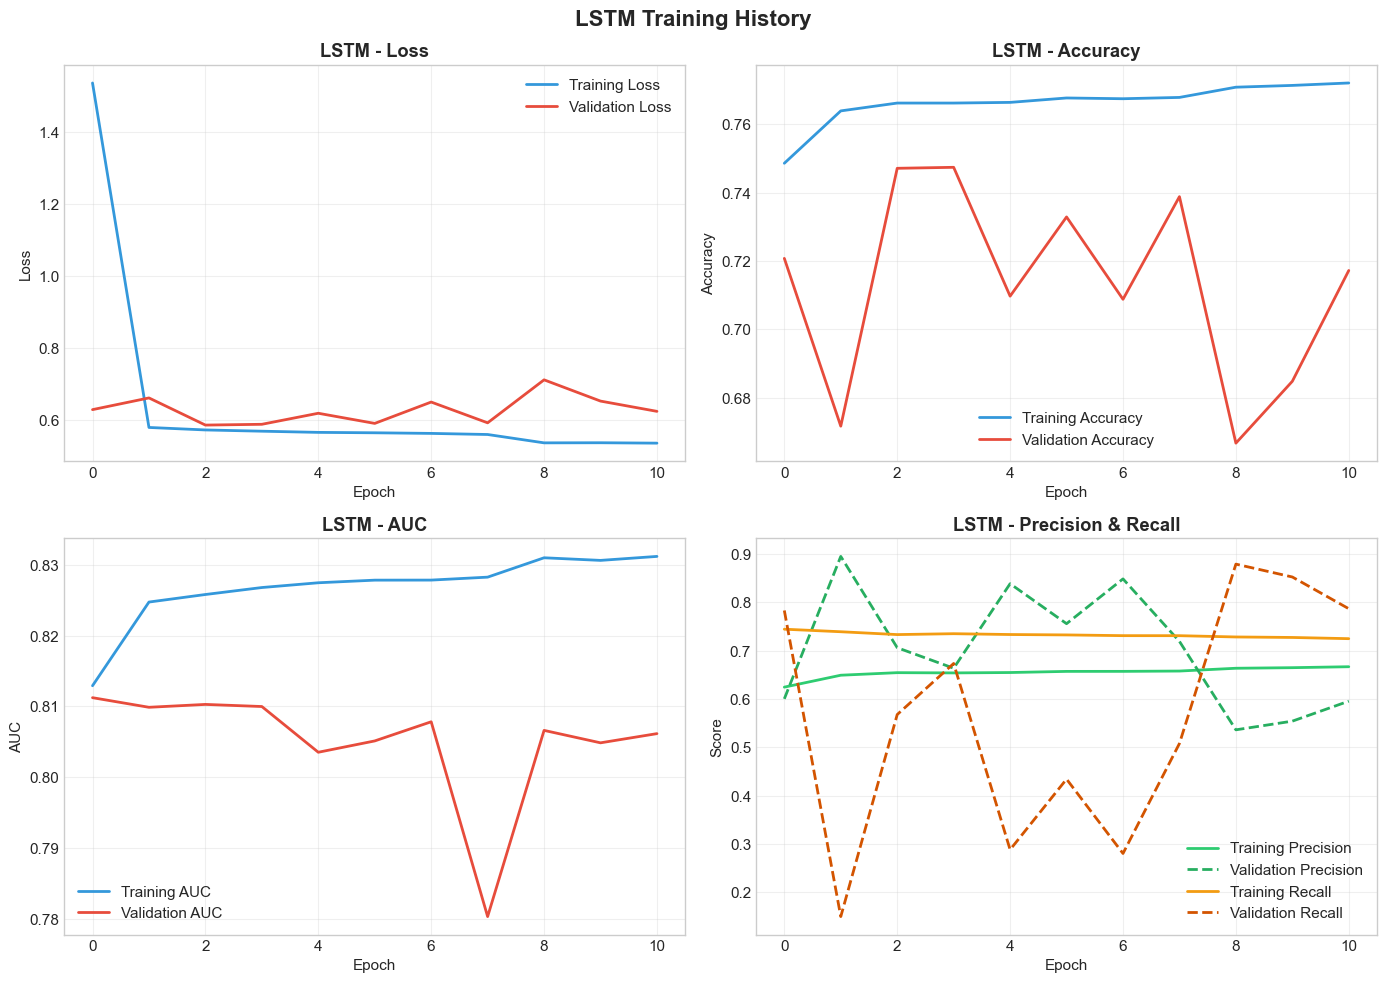

In [23]:
# =============================================================================
# PLOT LSTM TRAINING HISTORY
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot Loss
ax = axes[0, 0]
ax.plot(lstm_history.history['loss'], label='Training Loss', color='#3498db', linewidth=2)
ax.plot(lstm_history.history['val_loss'], label='Validation Loss', color='#e74c3c', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('LSTM - Loss', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot Accuracy
ax = axes[0, 1]
ax.plot(lstm_history.history['accuracy'], label='Training Accuracy', color='#3498db', linewidth=2)
ax.plot(lstm_history.history['val_accuracy'], label='Validation Accuracy', color='#e74c3c', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('LSTM - Accuracy', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot AUC
ax = axes[1, 0]
ax.plot(lstm_history.history['auc'], label='Training AUC', color='#3498db', linewidth=2)
ax.plot(lstm_history.history['val_auc'], label='Validation AUC', color='#e74c3c', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('AUC')
ax.set_title('LSTM - AUC', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot Precision & Recall
ax = axes[1, 1]
ax.plot(lstm_history.history['precision'], label='Training Precision', color='#2ecc71', linewidth=2)
ax.plot(lstm_history.history['val_precision'], label='Validation Precision', color='#27ae60', linewidth=2, linestyle='--')
ax.plot(lstm_history.history['recall'], label='Training Recall', color='#f39c12', linewidth=2)
ax.plot(lstm_history.history['val_recall'], label='Validation Recall', color='#d35400', linewidth=2, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('Score')
ax.set_title('LSTM - Precision & Recall', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('LSTM Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
# =============================================================================
# STEP 14: TRAIN BIDIRECTIONAL LSTM MODEL
# =============================================================================

print("="*80)
print("🚀 TRAINING BIDIRECTIONAL LSTM MODEL")
print("="*80)

# Build Bidirectional LSTM model
bilstm_model = build_bidirectional_lstm((timesteps, n_features), units=64, dropout_rate=0.3)

print("\n📋 Bidirectional LSTM Model Summary:")
bilstm_model.summary()

# Train the model
print("\n🔄 Training Bidirectional LSTM...")
start_time = time.time()

bilstm_history = bilstm_model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('BiLSTM'),
    verbose=1
)

bilstm_training_time = time.time() - start_time
print(f"\n✅ Bidirectional LSTM Training Complete! Time: {bilstm_training_time:.2f}s")

# Evaluate on validation set
bilstm_val_results = bilstm_model.evaluate(X_val_seq, y_val, verbose=0)
print(f"\n📊 Bidirectional LSTM Validation Results:")
print(f"   Loss: {bilstm_val_results[0]:.4f}")
print(f"   Accuracy: {bilstm_val_results[1]:.4f}")
print(f"   AUC: {bilstm_val_results[2]:.4f}")
print(f"   Precision: {bilstm_val_results[3]:.4f}")
print(f"   Recall: {bilstm_val_results[4]:.4f}")

🚀 TRAINING BIDIRECTIONAL LSTM MODEL

📋 Bidirectional LSTM Model Summary:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 1, 128)         │        61,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 1, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,697 (428.50 KB)

 Trainable params: 109,313 (427.00 KB)

 Non-trainable params: 384 (1.50 KB)


🔄 Training Bidirectional LSTM...
Epoch 1/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7503 - auc: 0.8159 - loss: 2.8807 - precision: 0.6263 - recall: 0.7491 - val_accuracy: 0.6649 - val_auc: 0.8110 - val_loss: 0.7493 - val_precision: 0.5348 - val_recall: 0.8807 - learning_rate: 0.0010
Epoch 2/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7630 - auc: 0.8248 - loss: 0.6302 - precision: 0.6471 - recall: 0.7424 - val_accuracy: 0.7454 - val_auc: 0.8091 - val_loss: 0.6233 - val_precision: 0.6652 - val_recall: 0.6589 - learning_rate: 0.0010
Epoch 3/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7654 - auc: 0.8262 - loss: 0.6225 - precision: 0.6518 - recall: 0.7390 - val_accuracy: 0.6884 - val_auc: 0.8106 - val_loss: 0.6981 - val_precision: 0.5581 - val_recall: 0.8479 - learning_rate: 0.0010
Epoch 4/50
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7665 - auc: 0.8266 - loss: 0.6184 - precision: 0.6543 - recall: 0.7366 - val_accuracy: 0.6735 

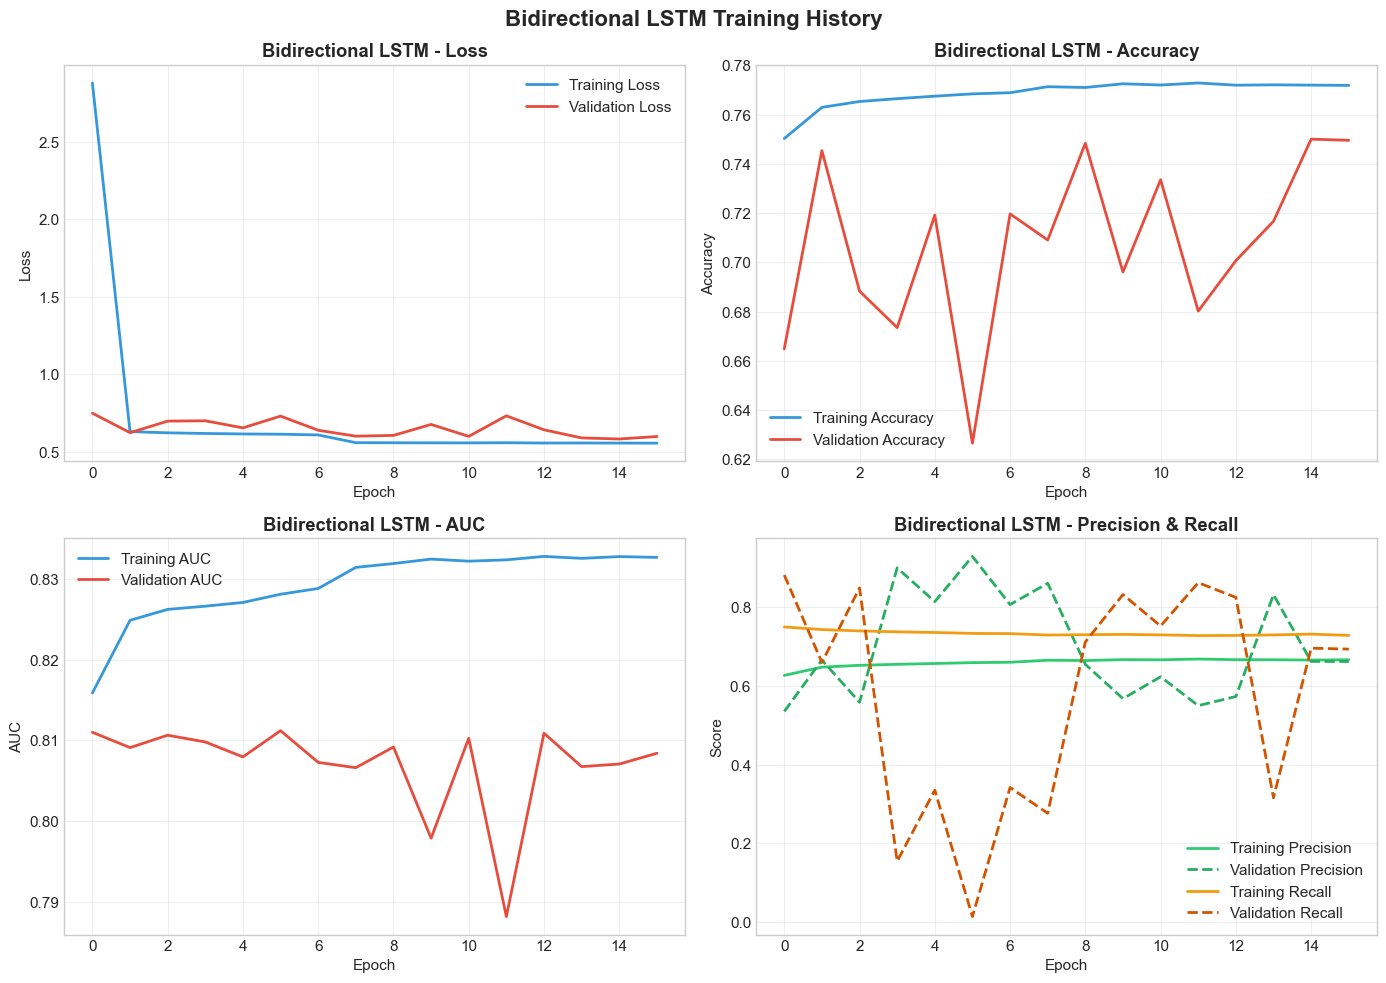

In [25]:
# =============================================================================
# PLOT BIDIRECTIONAL LSTM TRAINING HISTORY
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot Loss
ax = axes[0, 0]
ax.plot(bilstm_history.history['loss'], label='Training Loss', color='#3498db', linewidth=2)
ax.plot(bilstm_history.history['val_loss'], label='Validation Loss', color='#e74c3c', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Bidirectional LSTM - Loss', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot Accuracy
ax = axes[0, 1]
ax.plot(bilstm_history.history['accuracy'], label='Training Accuracy', color='#3498db', linewidth=2)
ax.plot(bilstm_history.history['val_accuracy'], label='Validation Accuracy', color='#e74c3c', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Bidirectional LSTM - Accuracy', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot AUC
ax = axes[1, 0]
ax.plot(bilstm_history.history['auc'], label='Training AUC', color='#3498db', linewidth=2)
ax.plot(bilstm_history.history['val_auc'], label='Validation AUC', color='#e74c3c', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('AUC')
ax.set_title('Bidirectional LSTM - AUC', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot Precision & Recall
ax = axes[1, 1]
ax.plot(bilstm_history.history['precision'], label='Training Precision', color='#2ecc71', linewidth=2)
ax.plot(bilstm_history.history['val_precision'], label='Validation Precision', color='#27ae60', linewidth=2, linestyle='--')
ax.plot(bilstm_history.history['recall'], label='Training Recall', color='#f39c12', linewidth=2)
ax.plot(bilstm_history.history['val_recall'], label='Validation Recall', color='#d35400', linewidth=2, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('Score')
ax.set_title('Bidirectional LSTM - Precision & Recall', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Bidirectional LSTM Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
# =============================================================================
# STEP 15: MODEL COMPARISON & EVALUATION ON VALIDATION SET
# =============================================================================

print("="*80)
print("📊 MODEL COMPARISON - VALIDATION SET RESULTS")
print("="*80)

# Define models and their results
models = {
    'Simple RNN': (rnn_model, rnn_val_results, rnn_training_time),
    'GRU': (gru_model, gru_val_results, gru_training_time),
    'LSTM': (lstm_model, lstm_val_results, lstm_training_time),
    'Bidirectional LSTM': (bilstm_model, bilstm_val_results, bilstm_training_time)
}

# Create comparison table
comparison_data = []
for model_name, (model, results, train_time) in models.items():
    comparison_data.append({
        'Model': model_name,
        'Val_Loss': results[0],
        'Val_Accuracy': results[1],
        'Val_AUC': results[2],
        'Val_Precision': results[3],
        'Val_Recall': results[4],
        'Training_Time (s)': train_time
    })

comparison_df = pd.DataFrame(comparison_data)

# Calculate F1 Score for each model
for model_name, (model, _, _) in models.items():
    y_val_pred = (model.predict(X_val_seq, verbose=0) > 0.5).astype(int).flatten()
    f1 = f1_score(y_val, y_val_pred)
    comparison_df.loc[comparison_df['Model'] == model_name, 'Val_F1'] = f1

# Sort by AUC
comparison_df = comparison_df.sort_values('Val_AUC', ascending=False)

print("\n📋 VALIDATION SET PERFORMANCE (Sorted by AUC):\n")
print(comparison_df.to_string(index=False))

# Identify best model
best_model_name = comparison_df.iloc[0]['Model']
best_model_info = models[best_model_name]

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   AUC: {comparison_df.iloc[0]['Val_AUC']:.4f}")
print(f"   Accuracy: {comparison_df.iloc[0]['Val_Accuracy']:.4f}")
print(f"   F1-Score: {comparison_df.iloc[0]['Val_F1']:.4f}")

📊 MODEL COMPARISON - VALIDATION SET RESULTS

📋 VALIDATION SET PERFORMANCE (Sorted by AUC):

             Model  Val_Loss  Val_Accuracy  Val_AUC  Val_Precision  Val_Recall  Training_Time (s)   Val_F1
        Simple RNN  0.583434      0.742426 0.812154       0.640175    0.729288          27.656996 0.681833
               GRU  0.618391      0.693730 0.811485       0.879656    0.220923          38.992869 0.353153
              LSTM  0.628893      0.720792 0.811235       0.600510    0.783305          29.697361 0.679834
Bidirectional LSTM  0.730477      0.626617 0.811211       0.927954    0.014482          57.025086 0.028520

🏆 BEST MODEL: Simple RNN
   AUC: 0.8122
   Accuracy: 0.7424
   F1-Score: 0.6818


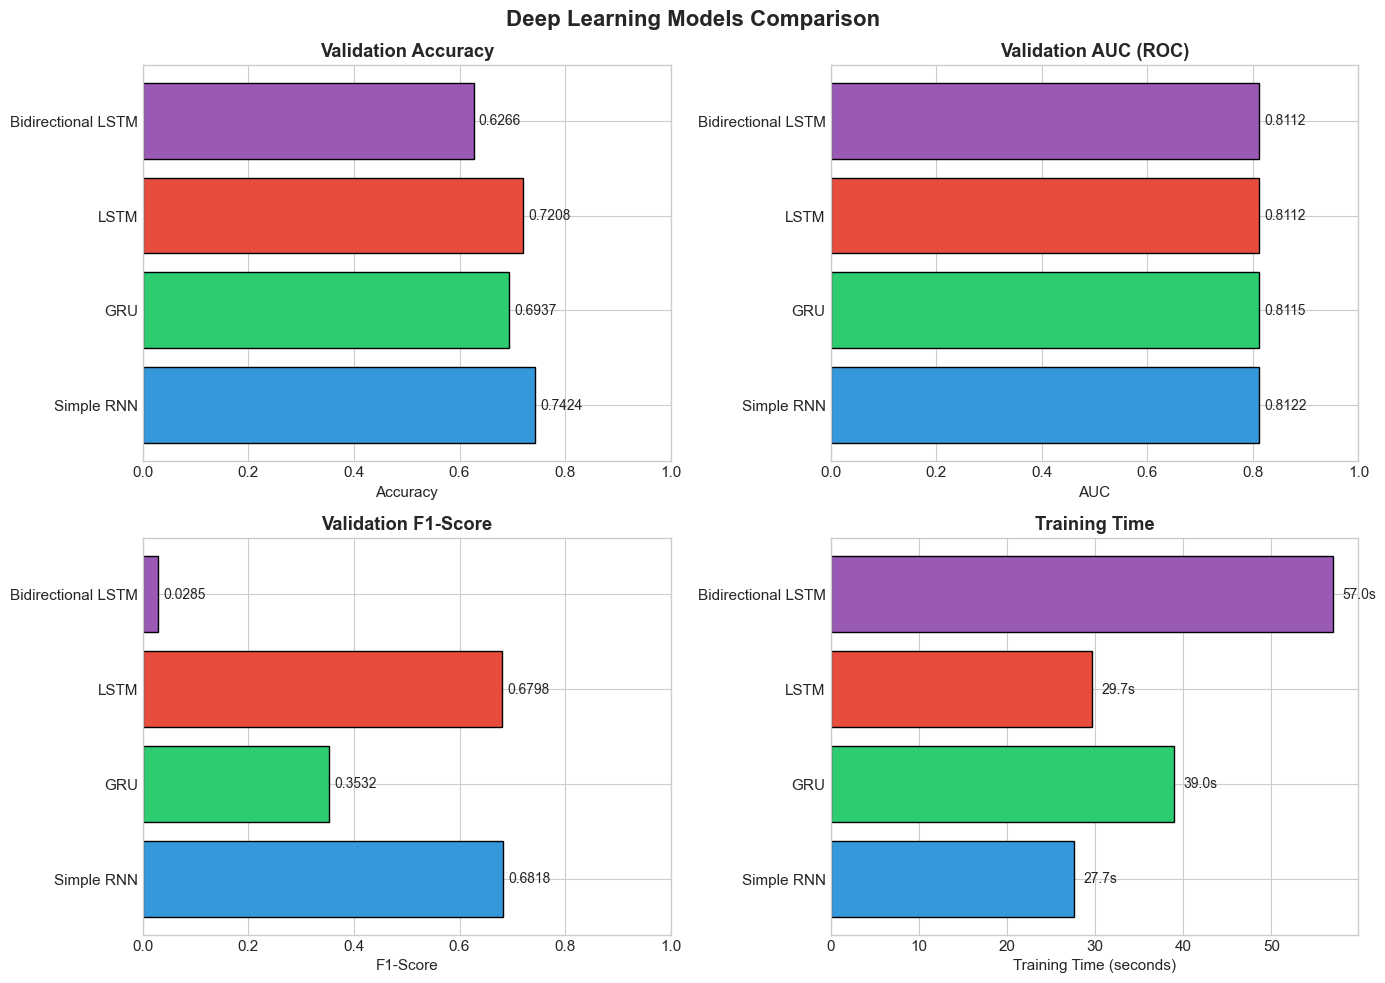

In [27]:
# =============================================================================
# VISUALIZE MODEL COMPARISON
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

model_names = comparison_df['Model'].tolist()
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

# 1. Accuracy Comparison
ax = axes[0, 0]
bars = ax.barh(model_names, comparison_df['Val_Accuracy'].tolist(), color=colors, edgecolor='black')
ax.set_xlabel('Accuracy')
ax.set_title('Validation Accuracy', fontweight='bold')
ax.set_xlim(0, 1)
for bar, val in zip(bars, comparison_df['Val_Accuracy'].tolist()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{val:.4f}', va='center', fontsize=10)

# 2. AUC Comparison
ax = axes[0, 1]
bars = ax.barh(model_names, comparison_df['Val_AUC'].tolist(), color=colors, edgecolor='black')
ax.set_xlabel('AUC')
ax.set_title('Validation AUC (ROC)', fontweight='bold')
ax.set_xlim(0, 1)
for bar, val in zip(bars, comparison_df['Val_AUC'].tolist()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{val:.4f}', va='center', fontsize=10)

# 3. F1-Score Comparison
ax = axes[1, 0]
bars = ax.barh(model_names, comparison_df['Val_F1'].tolist(), color=colors, edgecolor='black')
ax.set_xlabel('F1-Score')
ax.set_title('Validation F1-Score', fontweight='bold')
ax.set_xlim(0, 1)
for bar, val in zip(bars, comparison_df['Val_F1'].tolist()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{val:.4f}', va='center', fontsize=10)

# 4. Training Time Comparison
ax = axes[1, 1]
bars = ax.barh(model_names, comparison_df['Training_Time (s)'].tolist(), color=colors, edgecolor='black')
ax.set_xlabel('Training Time (seconds)')
ax.set_title('Training Time', fontweight='bold')
for bar, val in zip(bars, comparison_df['Training_Time (s)'].tolist()):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
            f'{val:.1f}s', va='center', fontsize=10)

plt.suptitle('Deep Learning Models Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

📈 ROC CURVES COMPARISON


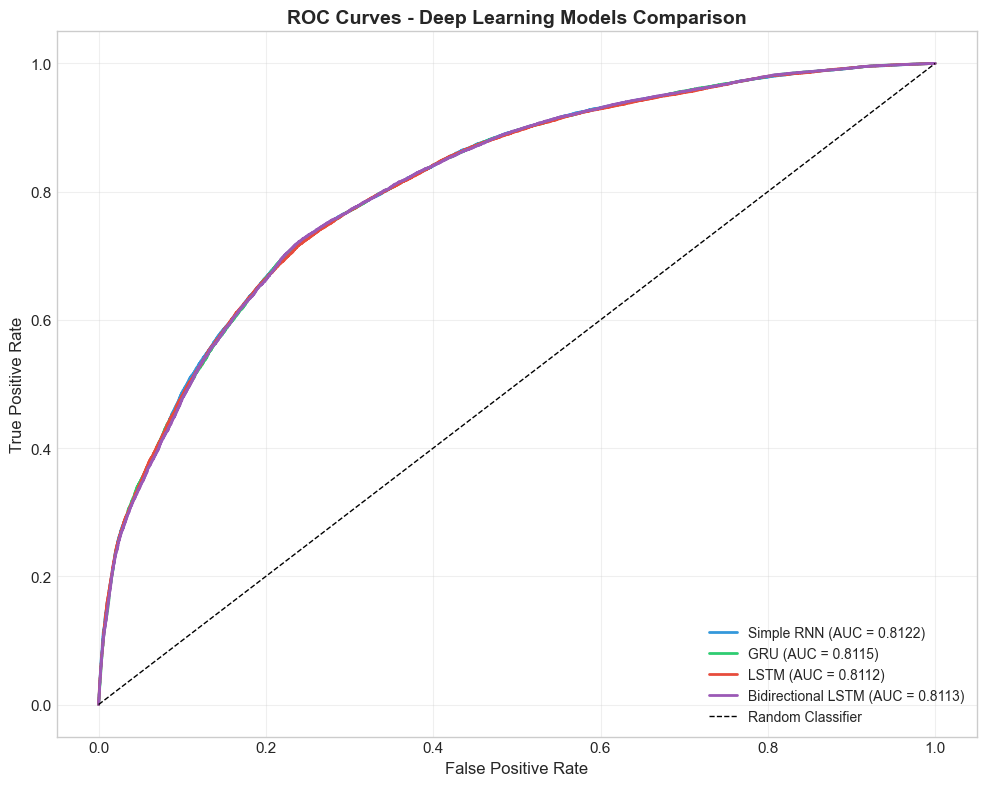


📈 PRECISION-RECALL CURVES


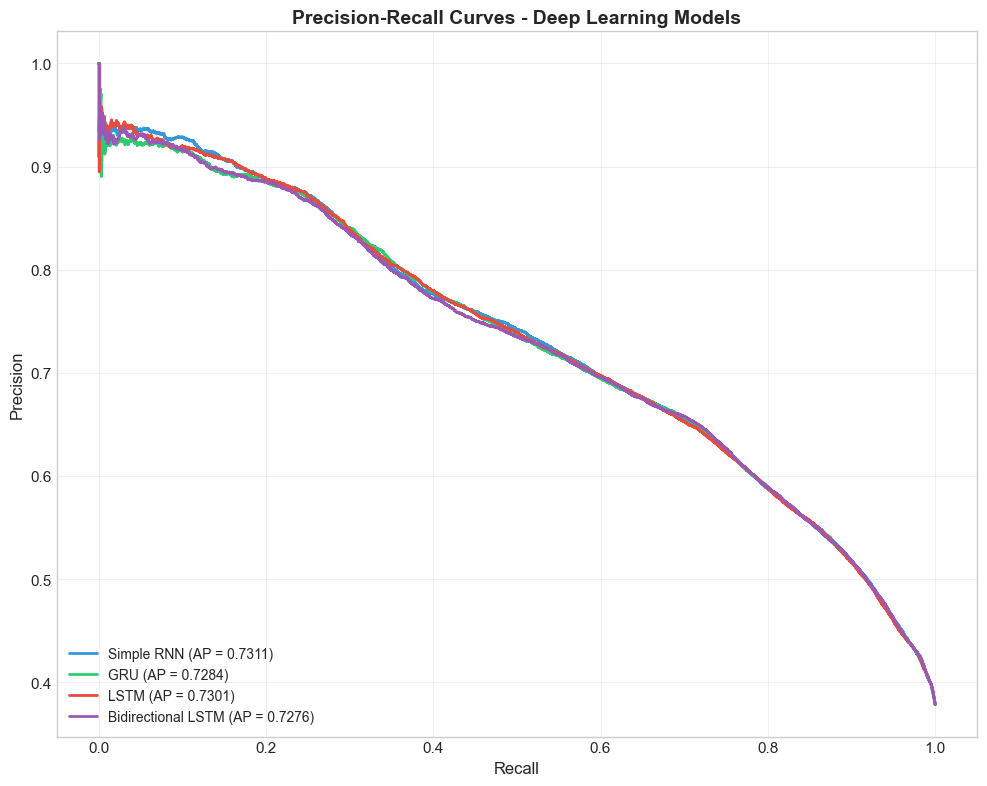

In [28]:
# =============================================================================
# ROC CURVES COMPARISON
# =============================================================================

print("="*80)
print("📈 ROC CURVES COMPARISON")
print("="*80)

fig, ax = plt.subplots(figsize=(10, 8))

colors = {'Simple RNN': '#3498db', 'GRU': '#2ecc71', 'LSTM': '#e74c3c', 'Bidirectional LSTM': '#9b59b6'}

for model_name, (model, _, _) in models.items():
    # Get predictions
    y_val_proba = model.predict(X_val_seq, verbose=0).flatten()
    
    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_val, y_val_proba)
    auc_score = roc_auc_score(y_val, y_val_proba)
    
    # Plot
    ax.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.4f})', 
            color=colors[model_name], linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Deep Learning Models Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Precision-Recall Curves
print("\n📈 PRECISION-RECALL CURVES")
fig, ax = plt.subplots(figsize=(10, 8))

for model_name, (model, _, _) in models.items():
    y_val_proba = model.predict(X_val_seq, verbose=0).flatten()
    precision, recall, _ = precision_recall_curve(y_val, y_val_proba)
    ap = average_precision_score(y_val, y_val_proba)
    ax.plot(recall, precision, label=f'{model_name} (AP = {ap:.4f})', 
            color=colors[model_name], linewidth=2)

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves - Deep Learning Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
# =============================================================================
# STEP 16: FINAL TEST SET EVALUATION
# =============================================================================

print("="*80)
print("🏆 FINAL TEST SET EVALUATION (15% Hold-out Data)")
print("="*80)

# Evaluate all models on test set
test_results = []

for model_name, (model, _, train_time) in models.items():
    # Get predictions
    y_test_proba = model.predict(X_test_seq, verbose=0).flatten()
    y_test_pred = (y_test_proba > 0.5).astype(int)
    
    # Calculate metrics
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    test_auc = roc_auc_score(y_test, y_test_proba)
    test_ap = average_precision_score(y_test, y_test_proba)
    
    test_results.append({
        'Model': model_name,
        'Test_Accuracy': test_accuracy,
        'Test_Precision': test_precision,
        'Test_Recall': test_recall,
        'Test_F1': test_f1,
        'Test_AUC': test_auc,
        'Test_AP': test_ap
    })
    
    print(f"\n{model_name}:")
    print(f"   Accuracy:  {test_accuracy:.4f}")
    print(f"   Precision: {test_precision:.4f}")
    print(f"   Recall:    {test_recall:.4f}")
    print(f"   F1-Score:  {test_f1:.4f}")
    print(f"   AUC-ROC:   {test_auc:.4f}")
    print(f"   AP:        {test_ap:.4f}")

# Create test results DataFrame
test_results_df = pd.DataFrame(test_results).sort_values('Test_AUC', ascending=False)

print("\n" + "="*80)
print("📋 TEST SET PERFORMANCE SUMMARY (Sorted by AUC):")
print("="*80)
print(test_results_df.to_string(index=False))

# Best model on test set
best_test_model = test_results_df.iloc[0]['Model']
print(f"\n🏆 BEST MODEL ON TEST SET: {best_test_model}")
print(f"   Test AUC: {test_results_df.iloc[0]['Test_AUC']:.4f}")
print(f"   Test F1:  {test_results_df.iloc[0]['Test_F1']:.4f}")

🏆 FINAL TEST SET EVALUATION (15% Hold-out Data)

Simple RNN:
   Accuracy:  0.7322
   Precision: 0.6683
   Recall:    0.8012
   F1-Score:  0.7287
   AUC-ROC:   0.8171
   AP:        0.7808

GRU:
   Accuracy:  0.6815
   Precision: 0.8636
   Recall:    0.3450
   F1-Score:  0.4931
   AUC-ROC:   0.8163
   AP:        0.7789

LSTM:
   Accuracy:  0.7069
   Precision: 0.6292
   Recall:    0.8449
   F1-Score:  0.7213
   AUC-ROC:   0.8153
   AP:        0.7770

Bidirectional LSTM:
   Accuracy:  0.5599
   Precision: 0.9313
   Recall:    0.0213
   F1-Score:  0.0416
   AUC-ROC:   0.8167
   AP:        0.7773

📋 TEST SET PERFORMANCE SUMMARY (Sorted by AUC):
             Model  Test_Accuracy  Test_Precision  Test_Recall  Test_F1  Test_AUC  Test_AP
        Simple RNN       0.732159        0.668252     0.801230 0.728725  0.817052 0.780820
Bidirectional LSTM       0.559853        0.931276     0.021277 0.041604  0.816655 0.777337
               GRU       0.681457        0.863640     0.345019 0.493062  0.8162

📊 CONFUSION MATRICES - TEST SET (15% Hold-out)


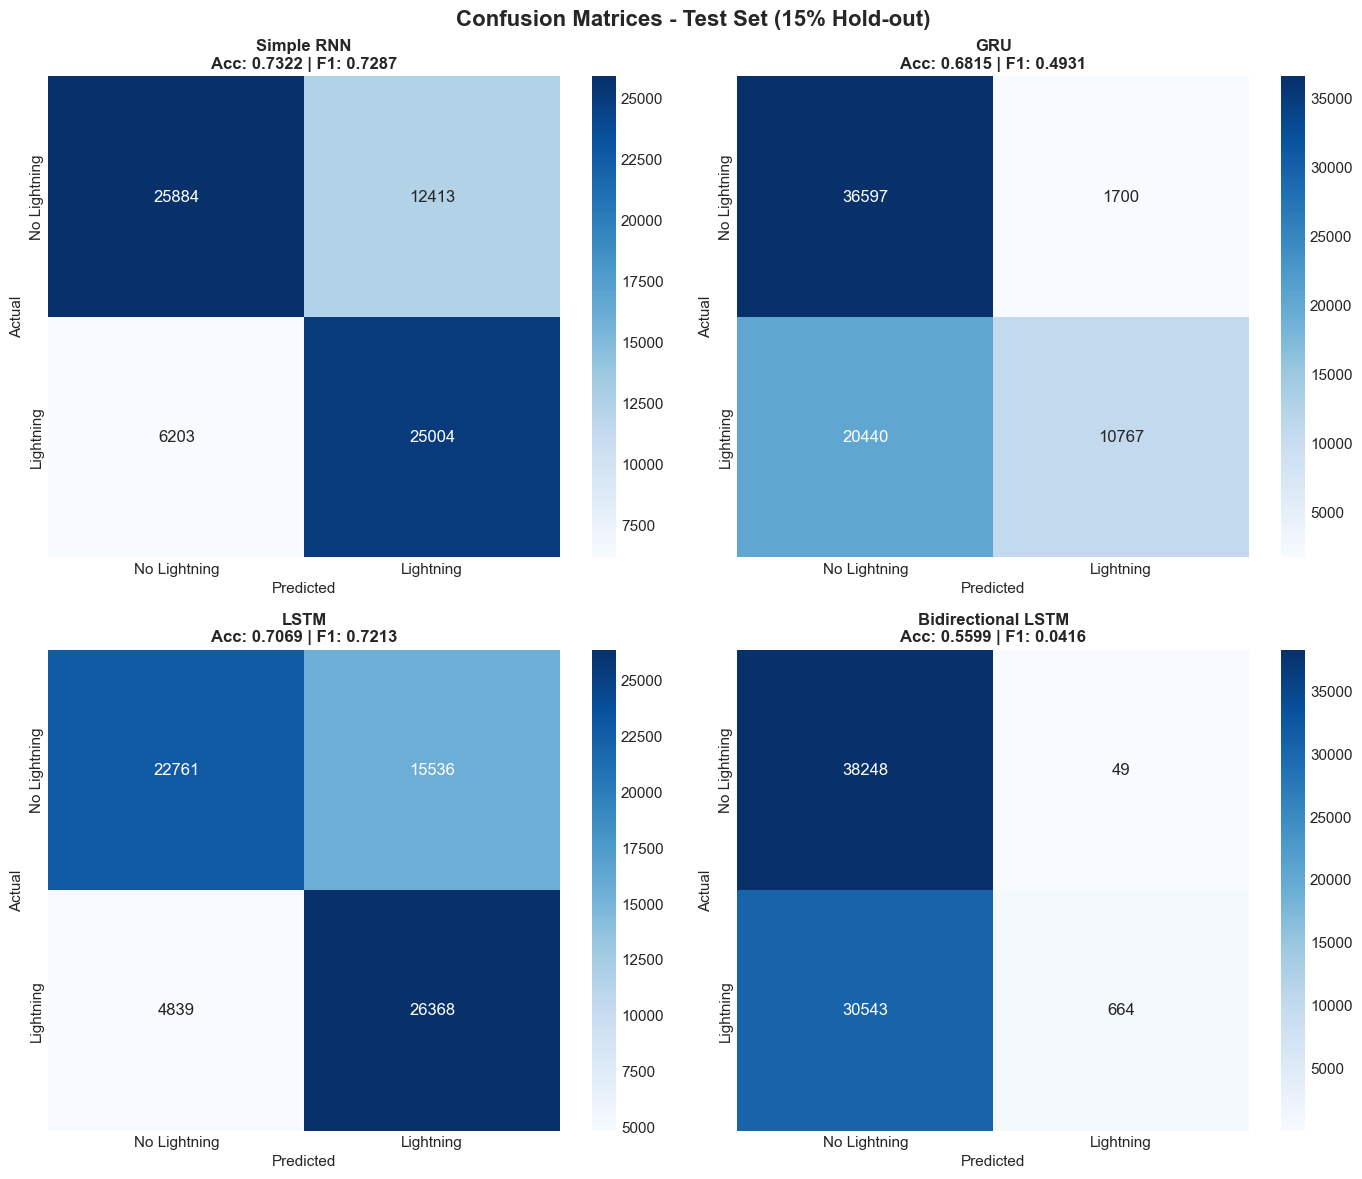


📋 DETAILED CLASSIFICATION REPORT - Simple RNN
              precision    recall  f1-score   support

No Lightning       0.81      0.68      0.74     38297
   Lightning       0.67      0.80      0.73     31207

    accuracy                           0.73     69504
   macro avg       0.74      0.74      0.73     69504
weighted avg       0.74      0.73      0.73     69504



In [30]:
# =============================================================================
# CONFUSION MATRICES FOR ALL MODELS ON TEST SET
# =============================================================================

print("="*80)
print("📊 CONFUSION MATRICES - TEST SET (15% Hold-out)")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (model_name, (model, _, _)) in enumerate(models.items()):
    ax = axes[idx]
    
    # Get predictions
    y_test_proba = model.predict(X_test_seq, verbose=0).flatten()
    y_test_pred = (y_test_proba > 0.5).astype(int)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)
    
    # Plot
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Lightning', 'Lightning'],
                yticklabels=['No Lightning', 'Lightning'],
                annot_kws={'size': 12})
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    
    # Calculate accuracy for title
    acc = accuracy_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    ax.set_title(f'{model_name}\nAcc: {acc:.4f} | F1: {f1:.4f}', fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices - Test Set (15% Hold-out)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print detailed metrics for best model
print("\n" + "="*80)
print(f"📋 DETAILED CLASSIFICATION REPORT - {best_test_model}")
print("="*80)

best_model_obj = models[best_test_model][0]
y_test_pred_best = (best_model_obj.predict(X_test_seq, verbose=0).flatten() > 0.5).astype(int)
print(classification_report(y_test, y_test_pred_best, target_names=['No Lightning', 'Lightning']))

📊 FINAL MODEL COMPARISON - VALIDATION VS TEST

📋 VALIDATION VS TEST PERFORMANCE:

             Model  Val_Accuracy  Val_AUC   Val_F1  Test_Accuracy  Test_AUC  Test_F1
        Simple RNN      0.742426 0.812154 0.681833       0.732159  0.817052 0.728725
               GRU      0.693730 0.811485 0.353153       0.681457  0.816257 0.493062
              LSTM      0.720792 0.811235 0.679834       0.706851  0.815302 0.721314
Bidirectional LSTM      0.626617 0.811211 0.028520       0.559853  0.816655 0.041604


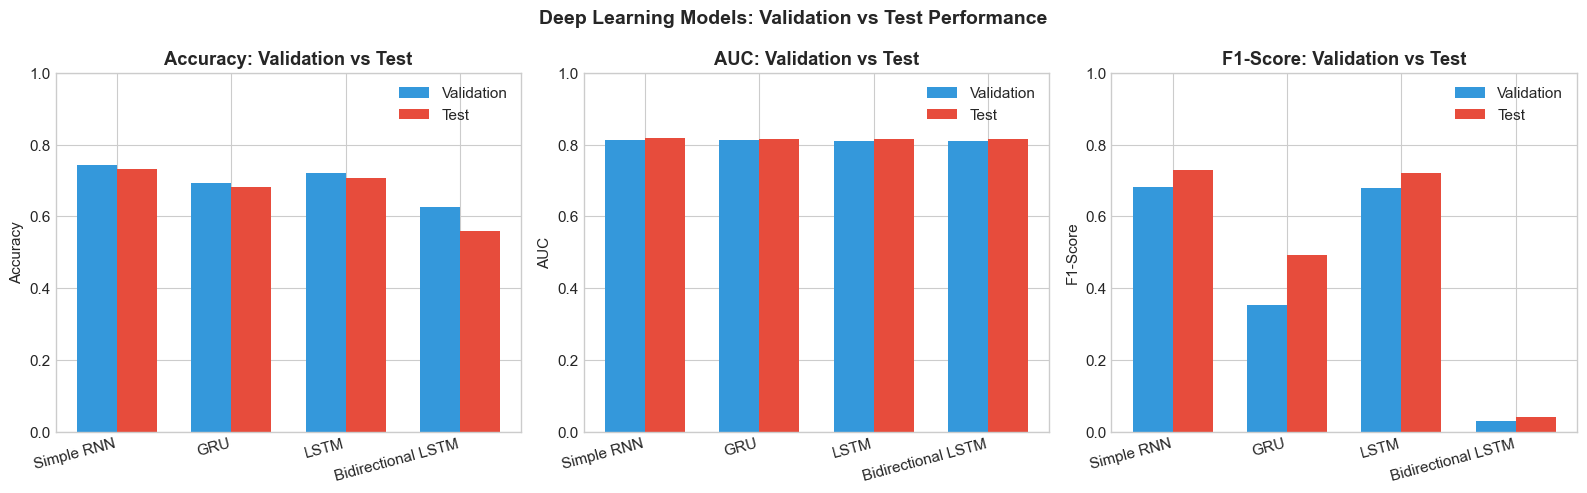

In [31]:
# =============================================================================
# FINAL COMPARISON VISUALIZATION
# =============================================================================

print("="*80)
print("📊 FINAL MODEL COMPARISON - VALIDATION VS TEST")
print("="*80)

# Merge validation and test results
merged_df = pd.merge(
    comparison_df[['Model', 'Val_Accuracy', 'Val_AUC', 'Val_F1']],
    test_results_df[['Model', 'Test_Accuracy', 'Test_AUC', 'Test_F1']],
    on='Model'
)

print("\n📋 VALIDATION VS TEST PERFORMANCE:\n")
print(merged_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_names = merged_df['Model'].tolist()
x = np.arange(len(model_names))
width = 0.35

# Accuracy
ax = axes[0]
bars1 = ax.bar(x - width/2, merged_df['Val_Accuracy'], width, label='Validation', color='#3498db')
bars2 = ax.bar(x + width/2, merged_df['Test_Accuracy'], width, label='Test', color='#e74c3c')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy: Validation vs Test', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1)

# AUC
ax = axes[1]
bars1 = ax.bar(x - width/2, merged_df['Val_AUC'], width, label='Validation', color='#3498db')
bars2 = ax.bar(x + width/2, merged_df['Test_AUC'], width, label='Test', color='#e74c3c')
ax.set_ylabel('AUC')
ax.set_title('AUC: Validation vs Test', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1)

# F1-Score
ax = axes[2]
bars1 = ax.bar(x - width/2, merged_df['Val_F1'], width, label='Validation', color='#3498db')
bars2 = ax.bar(x + width/2, merged_df['Test_F1'], width, label='Test', color='#e74c3c')
ax.set_ylabel('F1-Score')
ax.set_title('F1-Score: Validation vs Test', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1)

plt.suptitle('Deep Learning Models: Validation vs Test Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()